In [1]:
import re, os
import pandas as pd
import numpy as np

# ONLY use this folder to avoid duplicates
ENROLL_DIR = "./Medicare-Advantage/data/input/ma/enrollment"

enroll_zips = sorted(find_files("CPSC-Enrollment-*.zip"))
enroll_zips = [z for z in enroll_zips if z.startswith(ENROLL_DIR)]

# ONLY Jan 2010–2015 (6 files)
enroll_zips = [z for z in enroll_zips if re.search(r"CPSC-Enrollment-(2010|2011|2012|2013|2014|2015)-01\.zip$", z)]

print("Enrollment zips (should be 6):", len(enroll_zips))
print(enroll_zips)

NameError: name 'find_files' is not defined

In [ ]:
enroll_zips_all = sorted(find_files("CPSC-Enrollment-*.zip"))

# only 2010-2015 JANUARY files (6 files total)
enroll_zips = [z for z in enroll_zips_all if re.search(r"CPSC-Enrollment-(2010|2011|2012|2013|2014|2015)-01\.zip$", z)]

print("January-only zips:", len(enroll_zips))
print(enroll_zips[:10])

In [ ]:
dfs = []
for z in enroll_zips:
    d = read_one_enrollment_zip(z)
    if d is None:
        continue
    d["__source_zip"] = os.path.basename(z)
    d["year"] = int(re.search(r"CPSC-Enrollment-(\d{4})-", os.path.basename(z)).group(1))
    dfs.append(d)

enroll = pd.concat(dfs, ignore_index=True)

# Rename known columns
enroll = enroll.rename(columns={
    "Contract ID": "contract_id",
    "Plan ID": "plan_id",
    "Enrollment": "enroll",
    "Plan Type": "plan_type",
    "Offers Part D": "partd",
})

# Clean types
enroll["contract_id"] = enroll["contract_id"].astype(str).str.strip()

# plan_id sometimes reads float; keep as Int64 (nullable)
enroll["plan_id"] = pd.to_numeric(enroll["plan_id"], errors="coerce").astype("Int64")

# enrollment often has commas or weird stuff
enroll["enroll"] = (
    enroll["enroll"].astype(str)
    .str.replace(",", "", regex=False)
    .replace({"nan": np.nan, "": np.nan})
)
enroll["enroll"] = pd.to_numeric(enroll["enroll"], errors="coerce")

# drop junk rows
enroll = enroll.dropna(subset=["contract_id", "plan_id", "enroll"])

# market share per year
enroll["mkt_share"] = enroll["enroll"] / enroll.groupby("year")["enroll"].transform("sum")

enroll = enroll[["year","contract_id","plan_id","enroll","mkt_share","plan_type","partd"]].copy()

print("enroll shape:", enroll.shape)
print(enroll.groupby("year").size())
print(enroll.head())

In [ ]:
import glob, os, re, zipfile
import pandas as pd
import numpy as np

# ---------- 1) Rebuild enroll_zips (ONLY 2010-2015 January, ONLY data/input folder) ----------
BASE = "."  # adjust only if your notebook is not run from where Medicare-Advantage is visible

def find_files(pattern):
    return glob.glob(os.path.join(BASE, "**", pattern), recursive=True)

ENROLL_DIR = "./Medicare-Advantage/data/input/ma/enrollment"

enroll_zips = sorted(find_files("CPSC-Enrollment-201*-01.zip"))
enroll_zips = [z for z in enroll_zips if z.startswith(ENROLL_DIR)]
enroll_zips = [z for z in enroll_zips if re.search(r"CPSC-Enrollment-(2010|2011|2012|2013|2014|2015)-01\.zip$", z)]

print("Enrollment zips (should be 6):", len(enroll_zips))
print(enroll_zips)

# ---------- 2) Smarter zip reader: pick the CSV that actually has contract/plan/enroll ----------
def read_one_enrollment_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            return None

        best_name = None
        best_enc = None

        # scan each csv in the zip (first 5 rows) and pick the one with enrollment-like columns
        for name in csvs:
            with z.open(name) as f:
                for enc in ["utf-8", "cp1252", "latin1"]:
                    try:
                        tmp = pd.read_csv(f, encoding=enc, nrows=5, low_memory=False, on_bad_lines="skip")
                        cols = [c.lower().strip() for c in tmp.columns]

                        has_contract = any("contract" in c for c in cols)
                        has_plan = any("plan" in c for c in cols)
                        has_enroll = any("enroll" in c for c in cols)

                        if has_contract and has_plan and has_enroll:
                            best_name = name
                            best_enc = enc
                            break
                    except UnicodeDecodeError:
                        pass
                    finally:
                        try:
                            f.seek(0)
                        except Exception:
                            pass
                if best_name is not None:
                    break

        # fallback
        if best_name is None:
            best_name = csvs[0]
            best_enc = "latin1"

        with z.open(best_name) as f:
            df = pd.read_csv(f, encoding=best_enc, low_memory=False, on_bad_lines="skip")

    df["__source_csv"] = best_name
    return df

# ---------- 3) Standardize columns (works across years) ----------
def standardize_enroll_cols(d):
    cols = {c.lower().strip(): c for c in d.columns}

    def get(*names):
        for n in names:
            key = n.lower().strip()
            if key in cols:
                return cols[key]
        return None

    contract_col = get("Contract ID", "Contract Number", "Contract")
    plan_col     = get("Plan ID", "Plan Number", "Plan")
    enroll_col   = get("Enrollment", "Enrollments", "enrollment")
    plan_type_col= get("Plan Type")
    partd_col    = get("Offers Part D", "Offers Part D?", "Part D", "PartD")

    rename_map = {}
    if contract_col: rename_map[contract_col] = "contract_id"
    if plan_col:     rename_map[plan_col]     = "plan_id"
    if enroll_col:   rename_map[enroll_col]   = "enroll"
    if plan_type_col:rename_map[plan_type_col]= "plan_type"
    if partd_col:    rename_map[partd_col]    = "partd"

    d = d.rename(columns=rename_map).copy()

    for req in ["contract_id","plan_id","enroll"]:
        if req not in d.columns:
            d[req] = pd.NA

    return d

# ---------- 4) Load + clean ----------
dfs = []
for z in enroll_zips:
    d = read_one_enrollment_zip(z)
    if d is None:
        continue

    year = int(re.search(r"CPSC-Enrollment-(\d{4})-", os.path.basename(z)).group(1))
    d = standardize_enroll_cols(d)
    d["year"] = year
    d["__source_zip"] = os.path.basename(z)
    dfs.append(d)

enroll = pd.concat(dfs, ignore_index=True)

# keep missing as missing (avoid "nan" strings)
enroll["contract_id"] = enroll["contract_id"].astype("string").str.strip()
enroll["plan_id"] = pd.to_numeric(enroll["plan_id"], errors="coerce").astype("Int64")

# clean enrollment numbers
enroll["enroll"] = enroll["enroll"].astype("string").str.replace(",", "", regex=False)
enroll["enroll"] = pd.to_numeric(enroll["enroll"], errors="coerce")

# drop incomplete rows
enroll = enroll.dropna(subset=["contract_id","plan_id","enroll"])

# compute market share
enroll["mkt_share"] = enroll["enroll"] / enroll.groupby("year")["enroll"].transform("sum")

# ensure optional columns exist
for c in ["plan_type", "partd"]:
    if c not in enroll.columns:
        enroll[c] = pd.NA

# safe subset
keep = ["year","contract_id","plan_id","enroll","mkt_share","plan_type","partd"]
enroll = enroll.loc[:, keep].copy()

print("enroll shape:", enroll.shape)
print(enroll.groupby("year").size())
print(enroll.head())

print("enroll shape:", enroll.shape)
print(enroll.groupby("year").size())
print(enroll.head())

In [ ]:
import re, os, zipfile
import pandas as pd
import numpy as np

STAR_DIR = "./Medicare-Advantage/data/input/ma/star-ratings"

# grab the 2010-2015 star rating zips
star_zips = sorted(find_files("*Part-C-and-D-Medicare-Star-Ratings-Data.zip"))
star_zips = [z for z in star_zips if z.startswith(STAR_DIR)]
star_zips = [z for z in star_zips if re.search(r"/(2010|2011|2012|2013|2014|2015)-Part-C-and-D-Medicare-Star-Ratings-Data\.zip$", z)]

print("Star zips (should be 6):", len(star_zips))
print(star_zips)

def read_star_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            return None
        
        # pick a csv that looks like plan-level ratings
        pick = None
        for n in csvs:
            low = n.lower()
            if ("plan" in low and "rating" in low) or ("plan" in low and "star" in low):
                pick = n
                break
        if pick is None:
            pick = csvs[0]

        # read with encoding fallback
        with z.open(pick) as f:
            for enc in ["utf-8","cp1252","latin1"]:
                try:
                    df = pd.read_csv(f, encoding=enc, low_memory=False, on_bad_lines="skip")
                    break
                except UnicodeDecodeError:
                    f.seek(0)
            else:
                f.seek(0)
                df = pd.read_csv(f, encoding="latin1", encoding_errors="replace", low_memory=False, on_bad_lines="skip")

    df["__source_zip"] = os.path.basename(zpath)
    df["__source_csv"] = pick
    df["year"] = int(re.search(r"(2010|2011|2012|2013|2014|2015)", os.path.basename(zpath)).group(1))
    return df

star_raw = pd.concat([read_star_zip(z) for z in star_zips if read_star_zip(z) is not None], ignore_index=True)

print("star_raw shape:", star_raw.shape)
print("First 40 columns:", list(star_raw.columns)[:40])

# ---- auto-detect key columns ----
def find_col(df, keywords):
    # keywords: list of substrings that must all appear in column name (lower)
    for c in df.columns:
        low = c.lower()
        if all(k in low for k in keywords):
            return c
    return None

contract_col = find_col(star_raw, ["contract"])
plan_col     = find_col(star_raw, ["plan"])  # often "Plan ID"
# star rating candidates: look for overall + star + rating
star_col = find_col(star_raw, ["overall","star"]) or find_col(star_raw, ["star","rating"]) or find_col(star_raw, ["overall","rating"])

print("Detected columns:")
print("contract_col:", contract_col)
print("plan_col:", plan_col)
print("star_col:", star_col)

# if star_col is still None, show candidates
if star_col is None:
    cands = [c for c in star_raw.columns if "star" in c.lower() or "rating" in c.lower()]
    print("Rating-ish columns:", cands[:50])

In [ ]:
import glob
import pandas as pd
import numpy as np
import os

STAR_BASE = "./Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings"

# grab all summary files for 2012–2015
star_files = glob.glob(os.path.join(STAR_BASE, "**/*summary*.csv"), recursive=True)

print("Found summary files:", len(star_files))
print(star_files[:10])

In [ ]:
import glob
import pandas as pd
import numpy as np
import os

STAR_BASE = "./Medicare-Advantage/data/input/ma/star-ratings/Extracted Star Ratings"

# grab all summary files for 2012–2015
star_files = glob.glob(os.path.join(STAR_BASE, "**/*summary*.csv"), recursive=True)

print("Found summary files:", len(star_files))
print(star_files[:10])

In [ ]:
import os, glob, re
import pandas as pd
import numpy as np

# STAR_BASE already defined by you
star_files_all = glob.glob(os.path.join(STAR_BASE, "**/*summary*.csv"), recursive=True)

# keep only Part C folders and years 2010-2015 in the path
star_files = []
for f in star_files_all:
    low = f.lower()
    if "part c" not in low:
        continue
    if not any(str(y) in f for y in range(2010, 2016)):
        continue
    star_files.append(f)

star_files = sorted(star_files)

print("Part C summary files 2010-2015:", len(star_files))
for f in star_files[:20]:
    print(f)

In [ ]:
dfs = []
for f in star_files:
    try:
        tmp = pd.read_csv(f, low_memory=False)
    except Exception:
        # encoding fallback
        tmp = pd.read_csv(f, low_memory=False, encoding="latin1")

    # year from path
    year = None
    for y in range(2010, 2016):
        if str(y) in f:
            year = y
            break
    if year is None:
        continue

    tmp["year"] = year
    tmp["__source_file"] = os.path.basename(f)
    tmp["__source_path"] = f
    dfs.append(tmp)

star_raw = pd.concat(dfs, ignore_index=True)
print("star_raw shape:", star_raw.shape)

# show likely columns
print("contract-like:", [c for c in star_raw.columns if "contract" in c.lower()][:20])
print("plan-like:", [c for c in star_raw.columns if "plan" in c.lower()][:20])
print("star/rating-like:", [c for c in star_raw.columns if ("star" in c.lower() or "rating" in c.lower())][:40])

star_raw.head(3)

In [ ]:
# EDIT THESE THREE if needed based on the printed lists above:
CONTRACT_COL = [c for c in star_raw.columns if "contract" in c.lower()][0]
PLAN_COL     = [c for c in star_raw.columns if "plan" in c.lower() and "type" not in c.lower()][0]
STAR_COL     = [c for c in star_raw.columns if ("summary" in c.lower() and "star" in c.lower()) or ("overall" in c.lower() and "star" in c.lower()) or ("star rating" in c.lower())][0]

print("Using:", CONTRACT_COL, PLAN_COL, STAR_COL)

star = star_raw.rename(columns={
    CONTRACT_COL: "contract_id",
    PLAN_COL: "plan_id",
    STAR_COL: "star"
}).copy()

star["contract_id"] = star["contract_id"].astype("string").str.strip()
star["plan_id"] = pd.to_numeric(star["plan_id"], errors="coerce").astype("Int64")
star["star"] = pd.to_numeric(star["star"], errors="coerce")

star = star[["year","contract_id","plan_id","star"]].dropna(subset=["contract_id","plan_id"]).drop_duplicates()

df = enroll.merge(star, on=["year","contract_id","plan_id"], how="left")

print("Merged df shape:", df.shape)
print("Missing star share:", df["star"].isna().mean())
df.head()

In [ ]:
import pandas as pd
import numpy as np
import os, re, glob

STAR_BASE = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings"

# Use the two Part C 2014 summary files you found
star_files = sorted(glob.glob(os.path.join(STAR_BASE, "**/*Part_C*_summary.csv"), recursive=True))
star_files = [f for f in star_files if "2014" in f]  # keep it simple/fast

print("Using star summary files:", len(star_files))
for f in star_files:
    print(f)

def read_weird_summary_csv(path):
    raw = pd.read_csv(path, header=None, low_memory=False, encoding="latin1")
    # find row where first column equals "Contract Number" (header row)
    header_row = None
    for i in range(min(50, len(raw))):
        v = raw.iloc[i, 0]
        if isinstance(v, str) and v.strip().lower() == "contract number":
            header_row = i
            break
    if header_row is None:
        return None

    # set header and drop rows above header
    df = raw.iloc[header_row+1:].copy()
    df.columns = raw.iloc[header_row].astype(str).tolist()
    df = df.reset_index(drop=True)
    return df

stars_list = []
for f in star_files:
    df_s = read_weird_summary_csv(f)
    if df_s is None:
        continue

    # year: for 2014 Fall file, the folder name is 2014 but the "year" might be 2013 in your earlier output.
    # We'll just set year=2014 for these two files to match your enrollment years.
    df_s["year"] = 2014
    df_s["__source_file"] = os.path.basename(f)
    stars_list.append(df_s)

star_2014 = pd.concat(stars_list, ignore_index=True)

print("Parsed star_2014 columns:", [c for c in star_2014.columns if "rating" in c.lower() or "star" in c.lower()][:30])
print(star_2014.head(3)[["Contract Number"] + [c for c in star_2014.columns if "overall" in c.lower() and "rating" in c.lower()][:1]])

# pick an "overall rating" column
overall_cols = [c for c in star_2014.columns if ("overall" in c.lower() and "rating" in c.lower())]
if not overall_cols:
    overall_cols = [c for c in star_2014.columns if ("overall" in c.lower() and "star" in c.lower())]
OVERALL_COL = overall_cols[0]
print("Using overall column:", OVERALL_COL)

star_contract = star_2014[["year", "Contract Number", OVERALL_COL]].copy()
star_contract = star_contract.rename(columns={"Contract Number":"contract_id", OVERALL_COL:"star"})
star_contract["contract_id"] = star_contract["contract_id"].astype("string").str.strip()

# convert star to numeric (strings like 'Plan too new...' become NaN)
star_contract["star"] = pd.to_numeric(star_contract["star"], errors="coerce")

# MERGE at contract-year level (fast, good enough)
df = enroll.merge(star_contract, on=["year","contract_id"], how="left")

print("Merged df shape:", df.shape)
print("Share missing star:", df["star"].isna().mean())
df.head()

In [ ]:
q1 = df.groupby("year").agg(
    mean_star=("star","mean"),
    mean_enroll=("enroll","mean"),
    mean_mkt_share=("mkt_share","mean"),
    n_plans=("plan_id","count")
).reset_index()
q1

In [ ]:
q2 = df[df["star"].isna()].groupby("year").agg(
    mean_enroll=("enroll","mean"),
    mean_mkt_share=("mkt_share","mean"),
    n_nostar_plans=("plan_id","count")
).reset_index()
q2

In [ ]:
import matplotlib.pyplot as plt

# Average enrollment by star rating
enroll_by_star = df.groupby("star")["enroll"].mean()

plt.figure()
enroll_by_star.plot(kind="bar")
plt.ylabel("Average Enrollment")
plt.title("Average Enrollment by Star Rating")
plt.show()

# Market share by star rating
share_by_star = df.groupby("star")["mkt_share"].mean()

plt.figure()
share_by_star.plot(kind="bar")
plt.ylabel("Average Market Share")
plt.title("Market Share by Star Rating")
plt.show()

In [ ]:
import statsmodels.api as sm

reg = df.dropna(subset=["star","enroll","mkt_share"])

# Enrollment regression
X = sm.add_constant(reg["star"])
model1 = sm.OLS(reg["enroll"], X).fit()
print(model1.summary())

# Market share regression
X = sm.add_constant(reg["star"])
model2 = sm.OLS(reg["mkt_share"], X).fit()
print(model2.summary())

In [ ]:
import numpy as np

reg = df.dropna(subset=["star","enroll","mkt_share"])

# enrollment regression
coef = np.polyfit(reg["star"], reg["enroll"], 1)
print("Enrollment regression:")
print("intercept:", coef[1])
print("star coefficient:", coef[0])

# market share regression
coef2 = np.polyfit(reg["star"], reg["mkt_share"], 1)
print("\nMarket share regression:")
print("intercept:", coef2[1])
print("star coefficient:", coef2[0])

In [ ]:
import pandas as pd
import zipfile

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    with z.open("2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv") as f:
        star2010_raw = pd.read_csv(f, header=None, encoding="latin1")

star2010_raw.head()

In [ ]:
cols = star2010_raw.iloc[0].astype(str)

star2010 = star2010_raw.iloc[1:].copy()
star2010.columns = cols
star2010 = star2010.reset_index(drop=True)

star2010.head()

In [ ]:
star2010 = star2010.rename(columns={
    "Contract Number":"contract_id",
    "2010 Overall Rating":"star"
})

star2010["contract_id"] = star2010["contract_id"].astype("string").str.strip()

star2010["star"] = (
    star2010["star"]
    .astype(str)
    .str.extract(r'(\d\.?\d?)')
    .astype(float)
)

star2010.head()

In [ ]:
import pandas as pd
import numpy as np
import os, re, zipfile

ENROLL_ZIP_2010 = "./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip"
STAR_ZIP_2010   = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

print("enroll zip exists:", os.path.exists(ENROLL_ZIP_2010), ENROLL_ZIP_2010)
print("star zip exists:", os.path.exists(STAR_ZIP_2010), STAR_ZIP_2010)

def read_one_enrollment_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if len(csvs) == 0:
            return None
        # usually only one CSV inside
        name = csvs[0]
        with z.open(name) as f:
            # enrollment files sometimes have encoding weirdness
            try:
                df = pd.read_csv(f, low_memory=False)
            except UnicodeDecodeError:
                f.seek(0)
                df = pd.read_csv(f, low_memory=False, encoding="latin1")
    return df

In [ ]:
import pandas as pd
import numpy as np
import os, zipfile

# Try both common locations; pick the one that exists
ENROLL_ZIP_CANDIDATES = [
    "./Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip",
    "./Medicare-Advantage/data/input/ma/enrollment/CPSC-Enrollment-2010-01.zip",
]

ENROLL_ZIP_2010 = next((p for p in ENROLL_ZIP_CANDIDATES if os.path.exists(p)), None)
print("Using enrollment zip:", ENROLL_ZIP_2010)

def read_enrollment_csv_from_zip(zpath):
    """Return the first CSV inside the zip that contains an Enrollment column."""
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        print("CSV files inside zip:", csvs[:10], "..." if len(csvs) > 10 else "")
        for name in csvs:
            with z.open(name) as f:
                # try utf-8 then latin1
                try:
                    df = pd.read_csv(f, low_memory=False)
                except UnicodeDecodeError:
                    f.seek(0)
                    df = pd.read_csv(f, low_memory=False, encoding="latin1")

            # does it look like the enrollment file?
            cols_low = [c.lower() for c in df.columns]
            if any("enroll" in c for c in cols_low):
                print("Picked CSV:", name)
                return df
    return None

enr_raw = read_enrollment_csv_from_zip(ENROLL_ZIP_2010)
print("raw shape:", None if enr_raw is None else enr_raw.shape)
print("raw columns:", None if enr_raw is None else list(enr_raw.columns)[:25])

# If we STILL didn't find Enrollment, stop here
if enr_raw is None:
    raise ValueError("Could not find any CSV with an Enrollment column inside the zip. Try the other enrollment folder.")

# Standardize column names
colmap = {c.lower().strip(): c for c in enr_raw.columns}
def pick(*names):
    for n in names:
        key = n.lower()
        if key in colmap:
            return colmap[key]
    return None

contract_col = pick("Contract ID", "Contract Number", "Contract")
plan_col     = pick("Plan ID", "Plan Number", "Plan")
enroll_col   = pick("Enrollment", "Enrollments", "enrollment")
plan_type_col= pick("Plan Type")
partd_col    = pick("Offers Part D", "Offers Part D?", "Part D")

enroll2010 = enr_raw.rename(columns={
    contract_col: "contract_id",
    plan_col: "plan_id",
    enroll_col: "enroll",
    plan_type_col: "plan_type",
    partd_col: "partd",
}).copy()

enroll2010["year"] = 2010
enroll2010["contract_id"] = enroll2010["contract_id"].astype("string").str.strip()
enroll2010["plan_id"] = pd.to_numeric(enroll2010["plan_id"], errors="coerce").astype("Int64")

# Clean enroll numeric
enroll2010["enroll"] = enroll2010["enroll"].astype("string").str.replace(",", "", regex=False)
enroll2010["enroll"] = pd.to_numeric(enroll2010["enroll"], errors="coerce")

# indicators for Q9 (if present)
enroll2010["is_hmo"] = enroll2010.get("plan_type", pd.Series(pd.NA, index=enroll2010.index)).astype("string").str.contains("hmo", case=False, na=False)
enroll2010["is_partd"] = enroll2010.get("partd", pd.Series(pd.NA, index=enroll2010.index)).astype("string").str.lower().eq("yes")

enroll2010 = enroll2010.dropna(subset=["contract_id","plan_id","enroll"])
enroll2010["mkt_share"] = enroll2010["enroll"] / enroll2010["enroll"].sum()

print("enroll2010 shape:", enroll2010.shape)
enroll2010.head()

In [ ]:
import zipfile

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    with z.open("2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv") as f:
        star_raw = pd.read_csv(f, header=None, encoding="latin1")

# Fix header rows
cols = star_raw.iloc[1].astype(str).tolist()
star2010 = star_raw.iloc[2:].copy()
star2010.columns = cols
star2010 = star2010.reset_index(drop=True)

star2010.head()

In [ ]:
import pandas as pd, numpy as np, zipfile

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    with z.open("2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv") as f:
        star_raw = pd.read_csv(f, header=None, encoding="latin1", low_memory=False)

# row0 title, row1 header, row2+ data
cols = star_raw.iloc[1].astype(str).tolist()
star2010 = star_raw.iloc[2:].copy()
star2010.columns = cols
star2010 = star2010.reset_index(drop=True)

# clean contract id
star2010 = star2010.rename(columns={"Contract Number":"contract_id"})
star2010["contract_id"] = star2010["contract_id"].astype("string").str.strip()

# --- auto-detect which column contains numeric score (running var) ---
def numeric_count(col):
    s = star2010[col].astype("string")
    nums = s.str.extract(r"(\d+(\.\d+)?)")[0]
    return pd.to_numeric(nums, errors="coerce").notna().sum()

candidates = [c for c in star2010.columns if c != "contract_id"]
counts = {c: numeric_count(c) for c in candidates}
best_col = max(counts, key=counts.get)

print("Top numeric columns:")
top = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]
for c,n in top:
    print(n, "->", c)

print("\nUsing running column:", best_col)

star2010["running_raw"] = star2010[best_col].astype("string")
star2010["running"] = pd.to_numeric(star2010["running_raw"].str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce")

print("\nRows total:", len(star2010))
print("Rows with numeric running:", star2010["running"].notna().sum())

star2010[["contract_id","running_raw","running"]].head(12)

In [ ]:
star2010_clean = star2010.dropna(subset=["running"]).copy()
star2010_clean["star"] = np.round(star2010_clean["running"]*2)/2

df2010 = enroll2010.merge(
    star2010_clean[["contract_id","running","star"]],
    on="contract_id",
    how="left"
)

print("Missing running share in df2010:", df2010["running"].isna().mean())
df2010.head()

In [ ]:
star_counts = star2010_clean["star"].value_counts().sort_index()
star_counts

In [ ]:
cut = 2.75
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_3 = treat - control
rd_3

In [ ]:
cut = 3.25
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_35 = treat - control
rd_35

In [ ]:
df2010["running"].value_counts().sort_index()

In [ ]:
q5_table = (
    star2010_clean["star"]
    .value_counts()
    .sort_index()
    .reset_index()
)

q5_table.columns = ["Star Rating", "Number of Plans"]

q5_table

In [ ]:
cut = 2.75
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_3 = treat - control
rd_3

In [ ]:
cut = 3.25
bw = 0.25

rd = df2010[(df2010["running"] >= cut-bw) & (df2010["running"] <= cut+bw)]

treat = rd[rd["running"] >= cut]["enroll"].mean()
control = rd[rd["running"] < cut]["enroll"].mean()

rd_35 = treat - control
rd_35

In [ ]:
q6 = pd.DataFrame({
    "Threshold":[
        "3 stars vs 2.5 stars",
        "3.5 stars vs 3 stars"
    ],
    "RD Estimate (Enrollment Effect)":[
        rd_3,
        rd_35
    ]
})

q6

In [ ]:
q6["RD Estimate (Enrollment Effect)"] = q6["RD Estimate (Enrollment Effect)"].round(2)
q6

In [ ]:
bandwidths = [0.10,0.12,0.13,0.14,0.15]

results = []

for bw in bandwidths:

    # use a slightly wider filter to capture 2.5 and 3.0
    rd = df2010[(df2010["running"] >= 2.5) & (df2010["running"] <= 3.0)]

    treat = rd[rd["running"] >= 2.75]["enroll"].mean()
    control = rd[rd["running"] < 2.75]["enroll"].mean()

    effect3 = treat - control


    rd = df2010[(df2010["running"] >= 3.0) & (df2010["running"] <= 3.5)]

    treat = rd[rd["running"] >= 3.25]["enroll"].mean()
    control = rd[rd["running"] < 3.25]["enroll"].mean()

    effect35 = treat - control

    results.append([bw,effect3,effect35])

q7 = pd.DataFrame(results,columns=[
    "Bandwidth",
    "3 Star Effect",
    "3.5 Star Effect"
])

q7

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(q7["Bandwidth"], q7["3 Star Effect"], marker="o", label="3 star cutoff")
plt.plot(q7["Bandwidth"], q7["3.5 Star Effect"], marker="o", label="3.5 star cutoff")

plt.xlabel("Bandwidth")
plt.ylabel("RD Effect on Enrollment")
plt.title("RD Estimates Across Bandwidths")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import zipfile
import pandas as pd
import numpy as np
import re
from io import BytesIO

zip2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(zip2010) as z:
    # grab the .xls file
    xls_path = [n for n in z.namelist() if n.lower().endswith(".xls")][0]
    print("Using XLS:", xls_path)

    xls_bytes = BytesIO(z.read(xls_path))

# inspect sheets
xf = pd.ExcelFile(xls_bytes)
print("Sheets:", xf.sheet_names)

# read each sheet lightly and try to find a contract column + an overall score column
best = None

for sh in xf.sheet_names:
    tmp = pd.read_excel(xf, sheet_name=sh)
    cols = [str(c) for c in tmp.columns]

    contract_cols = [c for c in cols if "contract" in c.lower()]
    score_cols = [c for c in cols if ("summary" in c.lower() and "score" in c.lower()) or ("overall" in c.lower() and "rating" in c.lower())]

    if len(contract_cols) > 0 and len(score_cols) > 0:
        best = (sh, contract_cols[0], score_cols[0])
        break

print("Best guess (sheet, contract_col, score_col):", best)

In [ ]:
star2010_score = stars_data[[contract_col, best_col]].copy()
star2010_score.columns = ["contract_id", "running"]

star2010_score["contract_id"] = star2010_score["contract_id"].astype("string").str.strip()
star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")
star2010_score = star2010_score.dropna(subset=["running"])

print("Numeric running rows:", len(star2010_score))
star2010_score.head()

In [ ]:
!pip install xlrd

In [ ]:
summary = pd.read_excel(xf, sheet_name="Summary")
print("Summary shape:", summary.shape)
print("Summary columns (first 40):")
for c in summary.columns[:40]:
    print("-", c)

In [ ]:
import pandas as pd
import numpy as np

# Read the Summary sheet with no header so we can find the real header row
raw_sum = pd.read_excel(xf, sheet_name="Summary", header=None)
print("raw_sum shape:", raw_sum.shape)

# Find the row that contains "Contract" (that row is the real header)
header_idx = None
for i in range(min(30, len(raw_sum))):
    row_text = " ".join(raw_sum.iloc[i].astype(str).tolist()).lower()
    if "contract" in row_text:
        header_idx = i
        break

print("Detected header row index:", header_idx)
print("Header row preview:", raw_sum.iloc[header_idx].tolist())

# Build clean summary dataframe
cols = raw_sum.iloc[header_idx].astype(str).tolist()
summary = raw_sum.iloc[header_idx+1:].copy()
summary.columns = cols
summary = summary.reset_index(drop=True)

print("\nCleaned Summary columns:")
for c in summary.columns:
    print("-", c)

summary.head(5)

In [ ]:
# Contract col
contract_candidates = [c for c in summary.columns if "contract" in str(c).lower()]
print("Contract candidates:", contract_candidates)
contract_col = contract_candidates[0]

# Try to find a running-score column by name first
score_name_candidates = [
    c for c in summary.columns
    if any(k in str(c).lower() for k in ["summary score", "overall score", "summary", "overall"])
    and "star" not in str(c).lower()
]
print("\nScore name candidates:")
for c in score_name_candidates:
    print("-", c)

# If none by name, pick the most numeric column
def numeric_share(s):
    return pd.to_numeric(s, errors="coerce").notna().mean()

best_col = None
best_share = -1

for c in score_name_candidates:
    sh = numeric_share(summary[c])
    if sh > best_share:
        best_share = sh
        best_col = c

if best_col is None or best_share < 0.2:
    # fallback: choose most numeric overall (excluding contract col)
    shares = []
    for c in summary.columns:
        if c == contract_col: 
            continue
        shares.append((c, numeric_share(summary[c])))
    shares = sorted(shares, key=lambda x: x[1], reverse=True)
    print("\nTop numeric columns:")
    for c, sh in shares[:10]:
        print(f"{sh:.3f} | {c}")
    best_col, best_share = shares[0]

print("\nUSING running column:", best_col, "| numeric share:", best_share)

star2010_score = summary[[contract_col, best_col]].copy()
star2010_score.columns = ["contract_id", "running_raw"]
star2010_score["contract_id"] = star2010_score["contract_id"].astype("string").str.strip()

# Extract numeric running score even if mixed text
star2010_score["running"] = (
    star2010_score["running_raw"]
    .astype("string")
    .str.extract(r"(\d+(\.\d+)?)")[0]
)
star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")
star2010_score = star2010_score.dropna(subset=["running"])

print("Numeric running rows:", len(star2010_score))
star2010_score.head(10)

In [ ]:
star2010_score["running"].describe()

In [ ]:
df2010 = enroll2010.merge(star2010_score[["contract_id","running"]], on="contract_id", how="left")
print("Missing running share:", df2010["running"].isna().mean())
df2010["running"].describe()

In [ ]:
import matplotlib.pyplot as plt

def rd_effect(data, cutoff, bw):
    d = data.dropna(subset=["running","enroll"]).copy()
    w = d[(d["running"] >= cutoff-bw) & (d["running"] <= cutoff+bw)]
    if len(w)==0 or (w["running"] < cutoff).sum()==0 or (w["running"] >= cutoff).sum()==0:
        return np.nan
    return w[w["running"]>=cutoff]["enroll"].mean() - w[w["running"]<cutoff]["enroll"].mean()

bandwidths = [0.10,0.12,0.13,0.14,0.15]
rows = []
for bw in bandwidths:
    rows.append([bw, rd_effect(df2010, 2.75, bw), rd_effect(df2010, 3.25, bw)])

q7 = pd.DataFrame(rows, columns=["Bandwidth","3 Star Effect","3.5 Star Effect"])
q7

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(q7["Bandwidth"], q7["3 Star Effect"], marker="o", label="3-star cutoff (2.75)")
plt.plot(q7["Bandwidth"], q7["3.5 Star Effect"], marker="o", label="3.5-star cutoff (3.25)")
plt.xlabel("Bandwidth")
plt.ylabel("RD Effect on Enrollment")
plt.title("RD Estimates Across Bandwidths (2010)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt

STARZIP_2010 = "./Medicare-Advantage/ma-data/ma/star-ratings/Extracted Star Ratings/2010_Part_C Medicare_Star_Ratings_data.zip"

# -----------------------------
# Read the 2010 summary CSV (this has the summary score column)
# -----------------------------
with zipfile.ZipFile(STARZIP_2010) as z:
    members = z.namelist()
    summary_path = [m for m in members if m.endswith("_summary.csv")][0]
    raw = pd.read_csv(z.open(summary_path), header=None, encoding="latin1", low_memory=False)

# Find the header row (row that contains "Contract Number")
header_idx = None
for i in range(min(30, len(raw))):
    row = raw.iloc[i].astype(str).str.lower()
    if row.str.contains("contract number").any():
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Couldn't find the header row in summary.csv")

cols = raw.iloc[header_idx].astype(str).tolist()
star_summary = raw.iloc[header_idx+1:].copy()
star_summary.columns = cols
star_summary = star_summary.reset_index(drop=True)

# Identify columns we need
contract_col = [c for c in star_summary.columns if "contract number" in str(c).lower()][0]

# This is the running variable column in 2010 summary.csv
running_col = [c for c in star_summary.columns if "summary score" in str(c).lower()][0]

print("Using running column:", running_col)

# Build contract-level running variable dataset
star2010 = star_summary[[contract_col, running_col]].copy()
star2010.columns = ["contract_id", "running_raw"]
star2010["contract_id"] = star2010["contract_id"].astype("string").str.strip()

# Convert running_raw to numeric (extract first number if any)
star2010["running"] = (
    star2010["running_raw"]
    .astype("string")
    .str.extract(r"(\d+(\.\d+)?)")[0]
)
star2010["running"] = pd.to_numeric(star2010["running"], errors="coerce")

# Drop non-numeric rows ("plan too new", "not enough data", etc.)
star2010 = star2010.dropna(subset=["running"]).copy()

# Convert to star rating (rounded to nearest 0.5)
star2010["star"] = np.round(star2010["running"] * 2) / 2

print("star2010 numeric rows:", len(star2010))
print(star2010.head())
print(star2010["star"].value_counts().sort_index())

In [ ]:
# Merge running/star into your df2010 enrollment dataset
# (df2010 should already exist from your enrollment work)
df2010 = df2010.merge(star2010[["contract_id", "running", "star"]], on="contract_id", how="left")

print("Missing running share in df2010:", df2010["running"].isna().mean())

def rd_effect(data, cutoff, bw):
    d = data.dropna(subset=["running","enroll"]).copy()
    w = d[(d["running"] >= cutoff-bw) & (d["running"] <= cutoff+bw)]
    if len(w) == 0:
        return np.nan
    if (w["running"] < cutoff).sum() == 0 or (w["running"] >= cutoff).sum() == 0:
        return np.nan
    treat = w[w["running"] >= cutoff]["enroll"].mean()
    ctrl  = w[w["running"] <  cutoff]["enroll"].mean()
    return treat - ctrl

# Q6: bw = 0.125
bw0 = 0.125
cut_3  = 2.75
cut_35 = 3.25

eff3  = rd_effect(df2010, cut_3, bw0)
eff35 = rd_effect(df2010, cut_35, bw0)

q6 = pd.DataFrame({
    "Cutoff": ["3-star (2.75)", "3.5-star (3.25)"],
    "Bandwidth": [bw0, bw0],
    "RD effect on enrollment": [eff3, eff35]
})
q6

In [ ]:
# Q7: bandwidth sensitivity + graph
bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]
rows = []
for bw in bandwidths:
    rows.append([bw, rd_effect(df2010, cut_3, bw), rd_effect(df2010, cut_35, bw)])

q7 = pd.DataFrame(rows, columns=["Bandwidth", "3-star effect", "3.5-star effect"])
q7

In [ ]:
# sanity check: do these objects exist?
for name in ["enroll2010", "star2010_score"]:
    print(name, "exists?" , name in globals())

# if enroll2010 exists, check required columns
if "enroll2010" in globals():
    print("enroll2010 columns:", list(enroll2010.columns))
    print(enroll2010.head())

In [ ]:
import numpy as np
import pandas as pd

# df2010 needs: contract_id, enroll, is_hmo, is_partd, plus running
df2010 = enroll2010.merge(
    star2010_score[["contract_id", "running"]],  # or star2010[["contract_id","running"]]
    on="contract_id",
    how="left"
).dropna(subset=["running", "enroll"]).copy()

# star rating implied by rounding to nearest 0.5
df2010["star"] = np.round(df2010["running"] * 2) / 2

# "Rounded up into X-star" means running is below X but rounds to X
# Cutpoints for rounding to nearest 0.5 are at .25 above the lower half-step:
# 3.0 if running in [2.75, 3.25) rounds to 3.0, etc.
rounded_up_bins = {
    3.0:  (2.75, 3.00),
    3.5:  (3.25, 3.50),
    4.0:  (3.75, 4.00),
    4.5:  (4.25, 4.50),
    5.0:  (4.75, 5.00),
}

rows = []
for target, (lo, hi) in rounded_up_bins.items():
    # running in [lo, hi) is the “rounding up zone” into target
    n = ((df2010["running"] >= lo) & (df2010["running"] < hi)).sum()
    rows.append({"rounded_up_to_star": target, "running_interval": f"[{lo}, {hi})", "n_plans": int(n)})

q6_table = pd.DataFrame(rows)
q6_table

In [3]:
import os, zipfile, re
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# 1) SET THIS ONLY
# =========================
REPO_ROOT = Path(r"/PUT/YOUR/PATH/HERE")   # e.g. r"C:\Users\you\Documents\Medicare-Advantage"
# =========================

if not REPO_ROOT.exists():
    raise FileNotFoundError(f"REPO_ROOT does not exist: {REPO_ROOT}")

def find_one(patterns, root):
    """Return the first match among multiple glob patterns (searched in order)."""
    for pat in patterns:
        hits = list(root.glob(pat))
        if hits:
            return hits[0]
    return None

# -------------------------
# 2) Find enrollment zip for 2010
# -------------------------
enroll_zip = find_one(
    patterns=[
        "**/CPSC-Enrollment-2010-01.zip",
        "**/CPSC-Enrollment-2010*.zip",
        "**/CPSC-Enrollment-*.zip",
    ],
    root=REPO_ROOT
)
if enroll_zip is None:
    raise FileNotFoundError("Could not find CPSC-Enrollment-2010 zip under REPO_ROOT. "
                            "Try checking your repo has the ma-data/enrollment zips.")

print("Enrollment zip:", enroll_zip)

def read_best_csv_from_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            raise ValueError("No CSVs found inside enrollment zip.")
        best_df = None
        best_score = -1
        best_name = None
        for name in csvs:
            with z.open(name) as f:
                try:
                    df = pd.read_csv(f, low_memory=False)
                except UnicodeDecodeError:
                    f.seek(0)
                    df = pd.read_csv(f, low_memory=False, encoding="latin1")
            cols_low = [c.lower() for c in df.columns]
            score = 0
            score += sum("contract" in c for c in cols_low)
            score += sum("enroll" in c for c in cols_low)
            score += sum("market" in c for c in cols_low or [])
            if score > best_score:
                best_score = score
                best_df = df
                best_name = name
        print("Picked CSV inside zip:", best_name)
        return best_df

enr_raw = read_best_csv_from_zip(enroll_zip)
print("enr_raw shape:", enr_raw.shape)

# Standardize common columns
def pick_col(df, contains_any):
    cols = df.columns
    low = [str(c).lower() for c in cols]
    for i,c in enumerate(low):
        if any(k in c for k in contains_any):
            return cols[i]
    return None

contract_col = pick_col(enr_raw, ["contract"])
enroll_col   = pick_col(enr_raw, ["enroll"])
mshare_col   = pick_col(enr_raw, ["market share", "mkt share", "marketshare", "share"])

if contract_col is None or enroll_col is None:
    raise ValueError(f"Could not detect contract/enrollment columns. "
                     f"contract_col={contract_col}, enroll_col={enroll_col}")

enroll2010 = enr_raw[[contract_col, enroll_col] + ([mshare_col] if mshare_col else [])].copy()
enroll2010 = enroll2010.rename(columns={contract_col: "contract_id", enroll_col: "enroll"})
enroll2010["contract_id"] = enroll2010["contract_id"].astype("string").str.strip()
enroll2010["enroll"] = pd.to_numeric(enroll2010["enroll"], errors="coerce")

if mshare_col:
    enroll2010 = enroll2010.rename(columns={mshare_col: "market_share"})
    enroll2010["market_share"] = pd.to_numeric(enroll2010["market_share"], errors="coerce")

# Try to detect HMO / Part D status if present (not guaranteed in your enrollment extract)
# We'll create columns if we can; otherwise they will be NaN and later steps will still run.
hmo_col = pick_col(enr_raw, ["hmo"])
partd_col = pick_col(enr_raw, ["part d", "partd", "pdp", "drug"])
if hmo_col:
    enroll2010["is_hmo"] = enr_raw[hmo_col].astype("string").str.lower().isin(["1","true","yes","y","hmo"])
else:
    enroll2010["is_hmo"] = np.nan

if partd_col:
    enroll2010["is_partd"] = enr_raw[partd_col].astype("string").str.lower().isin(["1","true","yes","y"])
else:
    enroll2010["is_partd"] = np.nan

enroll2010 = enroll2010.dropna(subset=["contract_id", "enroll"])
print("enroll2010 shape:", enroll2010.shape)
print(enroll2010.head())

# -------------------------
# 3) Find 2010 star ratings zip (Part C)
# -------------------------
star_zip = find_one(
    patterns=[
        "**/2010_Part_C*Star_Ratings*data.zip",
        "**/*2010*Part*C*Star*Ratings*.zip",
        "**/*Star*Ratings*2010*.zip",
    ],
    root=REPO_ROOT
)
if star_zip is None:
    raise FileNotFoundError("Could not find 2010 Part C Star Ratings zip under REPO_ROOT.")

print("Star zip:", star_zip)

# Read the *_summary.csv inside the stars zip (usually contains Contract Number and Summary Score)
with zipfile.ZipFile(star_zip) as z:
    members = z.namelist()
    summary_candidates = [m for m in members if m.lower().endswith("_summary.csv")]
    if not summary_candidates:
        raise ValueError("No *_summary.csv found in 2010 star zip.")
    summary_path = summary_candidates[0]
    raw = pd.read_csv(z.open(summary_path), header=None, encoding="latin1", low_memory=False)

# Find the header row (contains 'Contract Number')
header_idx = None
for i in range(min(40, len(raw))):
    row = raw.iloc[i].astype(str).str.lower()
    if row.str.contains("contract number").any():
        header_idx = i
        break
if header_idx is None:
    raise ValueError("Couldn't find header row in star summary CSV.")

cols = raw.iloc[header_idx].astype(str).tolist()
summary = raw.iloc[header_idx+1:].copy()
summary.columns = cols
summary = summary.reset_index(drop=True)

contract_star_col = [c for c in summary.columns if "contract number" in str(c).lower()][0]

# Prefer a column that literally contains "summary score"; otherwise auto-pick the most numeric column (excluding contract)
score_candidates = [c for c in summary.columns if "summary score" in str(c).lower()]
if score_candidates:
    running_col = score_candidates[0]
else:
    def numeric_share(s):
        return pd.to_numeric(s.astype("string").str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce").notna().mean()
    best = None
    best_sh = -1
    for c in summary.columns:
        if c == contract_star_col:
            continue
        sh = numeric_share(summary[c])
        if sh > best_sh:
            best, best_sh = c, sh
    running_col = best

print("Using running column:", running_col)

star2010_score = summary[[contract_star_col, running_col]].copy()
star2010_score.columns = ["contract_id", "running_raw"]
star2010_score["contract_id"] = star2010_score["contract_id"].astype("string").str.strip()

star2010_score["running"] = (
    star2010_score["running_raw"]
    .astype("string")
    .str.extract(r"(\d+(\.\d+)?)")[0]
)
star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")
star2010_score = star2010_score.dropna(subset=["running"])

print("star2010_score shape:", star2010_score.shape)
print(star2010_score.head())

# -------------------------
# 4) Merge for RD work
# -------------------------
df2010 = enroll2010.merge(star2010_score[["contract_id","running"]], on="contract_id", how="left")
df2010 = df2010.dropna(subset=["running", "enroll"]).copy()
df2010["star"] = np.round(df2010["running"] * 2) / 2

print("df2010 shape:", df2010.shape)
print(df2010[["contract_id","enroll","running","star"]].head())

FileNotFoundError: REPO_ROOT does not exist: /PUT/YOUR/PATH/HERE

In [5]:
import pandas as pd
import zipfile

zip_path = "ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())

FileNotFoundError: [Errno 2] No such file or directory: 'ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip'

In [6]:
import os
print(os.getcwd())

/home/csleema/Homework 2/notebooks


In [7]:
import os
os.listdir("ma/star-ratings")

FileNotFoundError: [Errno 2] No such file or directory: 'ma/star-ratings'

In [8]:
import os
os.listdir("Medicare-Advantage")

['README.md',
 'python_code',
 'data',
 '.git',
 'stata_code',
 'ma-data',
 'R_code',
 '.gitignore']

In [9]:
os.listdir("Medicare-Advantage/ma-data/ma/star-ratings")

['2013-Part-C-and-D-Medicare-Plan-Ratings-Display-Measures-v013113.zip',
 '2019-Display-Measures.zip',
 '2012_Display_Measures.zip',
 '2016-Part-C-and-D-Medicare-Star-Ratings-Data-v10-06-2015.zip',
 '2022 Display Measures_0.zip',
 '2020 CAI Measure Selection Supplement.pdf',
 '2020_Display_Measures_2020_01_10.zip',
 '2011-Part-C-and-D-Medicare-Star-Ratings-Data.zip',
 '2022 Star Ratings and Display Measures.zip',
 '2023 Star Ratings Data Tables (Oct 04 2022).zip',
 '2008-Part-C-and-D-Medicare-Star-Ratings-Data.zip',
 '2023 Star Ratings and Display Measures.zip',
 '2017_Star_Ratings_and_Display_Measures.zip',
 '2020 Star Ratings Fact Sheet (Oct 10 2019).pdf',
 '2012-Part-C-and-D-Medicare-Star-Ratings-Data.zip',
 '2021 Star Ratings and Display Measures.zip',
 '2016_Star_Ratings_and_Display_Measures.zip',
 '2022 Star Ratings Fact Sheet_10_8_2021_1.pdf',
 'Extracted Star Ratings',
 '2015-Part-C-and-D-Medicare-Star-Ratings-Data.zip',
 '2007_Plan_Ratings (1).zip',
 'Star Ratings Technical No

In [10]:
from pathlib import Path
import zipfile, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("Medicare-Advantage")
STAR_ZIP = ROOT / "ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip"

# -------------------------
# Load 2010 stars: contract_id + running
# -------------------------
with zipfile.ZipFile(STAR_ZIP) as z:
    names = z.namelist()
    # pick a summary file (different zips name it slightly differently)
    summary_candidates = [n for n in names if n.lower().endswith(".csv") and "summary" in n.lower()]
    if not summary_candidates:
        raise ValueError("Could not find a *summary* CSV inside the 2010 star zip. "
                         "Print z.namelist() to inspect.")
    summary_name = summary_candidates[0]
    raw = pd.read_csv(z.open(summary_name), header=None, encoding="latin1", low_memory=False)

# find header row containing "Contract Number"
header_idx = None
for i in range(min(50, len(raw))):
    row = raw.iloc[i].astype(str).str.lower()
    if row.str.contains("contract number").any():
        header_idx = i
        break
if header_idx is None:
    raise ValueError("Couldn't find the header row in the star summary CSV.")

cols = raw.iloc[header_idx].astype(str).tolist()
summary = raw.iloc[header_idx+1:].copy()
summary.columns = cols
summary = summary.reset_index(drop=True)

contract_col = [c for c in summary.columns if "contract number" in str(c).lower()][0]

# choose running variable column:
# 1) prefer something with "summary score"
score_candidates = [c for c in summary.columns if "summary score" in str(c).lower()]
if score_candidates:
    running_col = score_candidates[0]
else:
    # 2) otherwise pick most-numeric column (excluding contract)
    def numeric_share(s):
        x = pd.to_numeric(s.astype("string").str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce")
        return x.notna().mean()
    best = None
    best_sh = -1
    for c in summary.columns:
        if c == contract_col:
            continue
        sh = numeric_share(summary[c])
        if sh > best_sh:
            best, best_sh = c, sh
    running_col = best

star2010_score = summary[[contract_col, running_col]].copy()
star2010_score.columns = ["contract_id", "running_raw"]
star2010_score["contract_id"] = star2010_score["contract_id"].astype("string").str.strip()

star2010_score["running"] = star2010_score["running_raw"].astype("string").str.extract(r"(\d+(\.\d+)?)")[0]
star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")
star2010_score = star2010_score.dropna(subset=["running"]).copy()
star2010_score["star"] = np.round(star2010_score["running"] * 2) / 2

print("Star summary file used:", summary_name)
print("Contract col:", contract_col)
print("Running col:", running_col)
print("star2010_score shape:", star2010_score.shape)
display(star2010_score.head())

# -------------------------
# Find & load 2010 enrollment file (auto-search)
# -------------------------
# We search for something that looks like CPSC Enrollment 2010
enroll_candidates = list(ROOT.rglob("*2010*Enrollment*.zip")) + list(ROOT.rglob("*Enrollment*2010*.zip"))
if not enroll_candidates:
    # try broader
    enroll_candidates = list(ROOT.rglob("*Enrollment*.zip"))

if not enroll_candidates:
    raise FileNotFoundError("Could not find an enrollment zip under the Medicare-Advantage folder.")

print("\nTop enrollment candidates:")
for p in enroll_candidates[:8]:
    print(" -", p)

ENROLL_ZIP = enroll_candidates[0]  # pick first; if wrong you can set it manually
print("\nUsing enrollment zip:", ENROLL_ZIP)

def read_best_csv_from_zip(zpath):
    with zipfile.ZipFile(zpath) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            raise ValueError("No CSVs found inside enrollment zip.")
        best_df = None
        best_score = -1
        best_name = None
        for name in csvs:
            with z.open(name) as f:
                try:
                    df = pd.read_csv(f, low_memory=False)
                except UnicodeDecodeError:
                    f.seek(0)
                    df = pd.read_csv(f, low_memory=False, encoding="latin1")
            cols_low = [str(c).lower() for c in df.columns]
            score = 0
            score += sum("contract" in c for c in cols_low)
            score += sum("enroll" in c for c in cols_low)
            score += sum("market" in c for c in cols_low)  # market share sometimes present
            if score > best_score:
                best_score, best_df, best_name = score, df, name
        print("Picked CSV inside enrollment zip:", best_name)
        return best_df

enr_raw = read_best_csv_from_zip(ENROLL_ZIP)

def pick_col(df, keys):
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in keys):
            return c
    return None

contract_e = pick_col(enr_raw, ["contract"])
enroll_e   = pick_col(enr_raw, ["enroll"])
mshare_e   = pick_col(enr_raw, ["market share", "marketshare", "mkt share", "share"])

if contract_e is None or enroll_e is None:
    raise ValueError(f"Could not identify contract/enroll columns in enrollment data. "
                     f"contract={contract_e}, enroll={enroll_e}")

enroll2010 = enr_raw[[contract_e, enroll_e] + ([mshare_e] if mshare_e else [])].copy()
enroll2010 = enroll2010.rename(columns={contract_e: "contract_id", enroll_e: "enroll"})
enroll2010["contract_id"] = enroll2010["contract_id"].astype("string").str.strip()
enroll2010["enroll"] = pd.to_numeric(enroll2010["enroll"], errors="coerce")

if mshare_e:
    enroll2010 = enroll2010.rename(columns={mshare_e: "market_share"})
    enroll2010["market_share"] = pd.to_numeric(enroll2010["market_share"], errors="coerce")
else:
    enroll2010["market_share"] = np.nan  # still lets RD run

# try to detect HMO / Part D status if present
hmo_e = pick_col(enr_raw, ["hmo"])
partd_e = pick_col(enr_raw, ["part d", "partd", "pdp", "drug"])

enroll2010["is_hmo"] = np.nan if hmo_e is None else enr_raw[hmo_e].astype("string").str.lower().isin(["1","true","yes","y","hmo"])
enroll2010["is_partd"] = np.nan if partd_e is None else enr_raw[partd_e].astype("string").str.lower().isin(["1","true","yes","y"])

enroll2010 = enroll2010.dropna(subset=["contract_id","enroll"]).copy()
print("enroll2010 shape:", enroll2010.shape)
display(enroll2010.head())

# -------------------------
# Merge for RD work (2010)
# -------------------------
df2010 = enroll2010.merge(star2010_score[["contract_id","running","star"]], on="contract_id", how="left")
df2010 = df2010.dropna(subset=["running","enroll"]).copy()
print("df2010 shape:", df2010.shape)
display(df2010.head())

# =========================================================
# Q6: Rounded-up counts table
# =========================================================
rounded_up_bins = {
    3.0: (2.75, 3.00),
    3.5: (3.25, 3.50),
    4.0: (3.75, 4.00),
    4.5: (4.25, 4.50),
    5.0: (4.75, 5.00),
}

q6_rows = []
for target, (lo, hi) in rounded_up_bins.items():
    n = ((df2010["running"] >= lo) & (df2010["running"] < hi)).sum()
    q6_rows.append({"rounded_up_to_star": target, "running_interval": f"[{lo}, {hi})", "n_plans": int(n)})

q6_table = pd.DataFrame(q6_rows)
print("\nQ6 table:")
display(q6_table)

# =========================================================
# RD helper + Q7/Q8/Q9
# =========================================================
def rd_diff_in_means(data, cutoff, bw, outcome="enroll"):
    d = data.dropna(subset=["running", outcome]).copy()
    w = d[(d["running"] >= cutoff - bw) & (d["running"] <= cutoff + bw)]
    below = w[w["running"] < cutoff]
    above = w[w["running"] >= cutoff]
    if len(below) == 0 or len(above) == 0:
        return np.nan, len(below), len(above)
    return above[outcome].mean() - below[outcome].mean(), len(below), len(above)

cut_3  = 2.75   # 2.5 -> 3.0
cut_35 = 3.25   # 3.0 -> 3.5

# Q7 (bw = 0.125)
bw = 0.125
eff3, n0_3, n1_3 = rd_diff_in_means(df2010, cut_3, bw, outcome="enroll")
eff35, n0_35, n1_35 = rd_diff_in_means(df2010, cut_35, bw, outcome="enroll")

q7 = pd.DataFrame([
    {"threshold": "3.0 vs 2.5 (cut=2.75)", "bandwidth": bw, "rd_effect": eff3, "n_below": n0_3, "n_above": n1_3},
    {"threshold": "3.5 vs 3.0 (cut=3.25)", "bandwidth": bw, "rd_effect": eff35, "n_below": n0_35, "n_above": n1_35},
])
print("\nQ7 RD results:")
display(q7)

# Q8 bandwidth sensitivity + graph
bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]
rows = []
for bw in bandwidths:
    e3,  a0, a1 = rd_diff_in_means(df2010, cut_3, bw, outcome="enroll")
    e35, b0, b1 = rd_diff_in_means(df2010, cut_35, bw, outcome="enroll")
    rows.append({"Bandwidth": bw, "Effect@3.0": e3, "Effect@3.5": e35,
                 "n_below_3": a0, "n_above_3": a1, "n_below_35": b0, "n_above_35": b1})
q8 = pd.DataFrame(rows)

print("\nQ8 sensitivity table:")
display(q8)

plt.figure(figsize=(8,5))
plt.plot(q8["Bandwidth"], q8["Effect@3.0"], marker="o", label="3.0 vs 2.5 (cut=2.75)")
plt.plot(q8["Bandwidth"], q8["Effect@3.5"], marker="o", label="3.5 vs 3.0 (cut=3.25)")
plt.axhline(0, linewidth=1)
plt.xlabel("Bandwidth")
plt.ylabel("RD effect on enrollment (diff-in-means)")
plt.title("Q8: RD estimates across bandwidths (2010)")
plt.grid(True)
plt.legend()
plt.show()

# Q9 manipulation histograms
def plot_running_hist(data, cutoff, window=0.6, binwidth=0.02, title=""):
    d = data.dropna(subset=["running"]).copy()
    d = d[(d["running"] >= cutoff-window) & (d["running"] <= cutoff+window)]
    bins = np.arange(cutoff-window, cutoff+window+binwidth, binwidth)
    plt.figure(figsize=(8,4))
    plt.hist(d["running"], bins=bins)
    plt.axvline(cutoff, linewidth=2)
    plt.title(title or f"Running variable distribution around cutoff {cutoff}")
    plt.xlabel("Running variable (continuous score)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

plot_running_hist(df2010, cut_3,  window=0.6, binwidth=0.02, title="Q9: Manipulation check around 2.75 (2.5→3.0)")
plot_running_hist(df2010, cut_35, window=0.6, binwidth=0.02, title="Q9: Manipulation check around 3.25 (3.0→3.5)")

ValueError: Could not find a *summary* CSV inside the 2010 star zip. Print z.namelist() to inspect.

In [11]:
import zipfile
from pathlib import Path

STAR_ZIP = Path("Medicare-Advantage/ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip")

with zipfile.ZipFile(STAR_ZIP) as z:
    names = z.namelist()
    print("Number of files:", len(names))
    for n in names:
        print(n)

Number of files: 2
2010_Part_C Medicare_Star_Ratings_data.zip
2010_Part_D Medicare_Star_Ratings_data.zip


In [12]:
import zipfile
from pathlib import Path

OUTER = Path("Medicare-Advantage/ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip")
INNER_NAME = "2010_Part_C Medicare_Star_Ratings_data.zip"

with zipfile.ZipFile(OUTER) as outer:
    with outer.open(INNER_NAME) as inner_bytes:
        # inner_bytes is a file-like object; ZipFile can open it directly
        with zipfile.ZipFile(inner_bytes) as inner:
            inner_names = inner.namelist()
            print("Number of files in Part C zip:", len(inner_names))
            for n in inner_names:
                print(n)

Number of files in Part C zip: 8
2010/
2010/2010_Part_C_Report_Card_Master_Table_2009_11_30.xls
2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_cutpoints.csv
2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_data.csv
2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_domain.csv
2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_stars.csv
2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv
2010/2010_Technical_Notes_for_Part_C_2010_07_30.pdf


In [13]:
import zipfile
import pandas as pd
import numpy as np
from pathlib import Path

OUTER = Path("Medicare-Advantage/ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip")
INNER_NAME = "2010_Part_C Medicare_Star_Ratings_data.zip"
SUMMARY_CSV = "2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv"

with zipfile.ZipFile(OUTER) as outer:
    with outer.open(INNER_NAME) as inner_bytes:
        with zipfile.ZipFile(inner_bytes) as inner:
            star_sum = pd.read_csv(inner.open(SUMMARY_CSV), low_memory=False)

print(star_sum.shape)
print(star_sum.columns.tolist())
star_sum.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xab in position 2275: invalid start byte

In [14]:
import zipfile
import pandas as pd
from pathlib import Path

OUTER = Path("Medicare-Advantage/ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip")
INNER_NAME = "2010_Part_C Medicare_Star_Ratings_data.zip"
SUMMARY_CSV = "2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_summary.csv"

with zipfile.ZipFile(OUTER) as outer:
    with outer.open(INNER_NAME) as inner_bytes:
        with zipfile.ZipFile(inner_bytes) as inner:
            # try cp1252 (windows-1252), fallback to latin1
            try:
                star_sum = pd.read_csv(inner.open(SUMMARY_CSV), encoding="cp1252", low_memory=False)
            except UnicodeDecodeError:
                star_sum = pd.read_csv(inner.open(SUMMARY_CSV), encoding="latin1", low_memory=False)

print(star_sum.shape)
print(star_sum.columns.tolist())
star_sum.head()

(710, 5)
['2010 Summary Star View: Medicare Part C Report Card Master Table', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,2010 Summary Star View: Medicare Part C Report Card Master Table,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Summary Score for Health Plan Quality
1,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Not enough data to calculate summary score
2,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Not enough data to calculate summary score
3,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Not enough data to calculate summary score
4,H0046,Local CCP,"Jaahel Group, Inc.",ProSalud Medicare Esencial Activo,Plan too new to be measured


In [15]:
# Fix header row
star_sum.columns = star_sum.iloc[0]
star_sum = star_sum.iloc[1:].reset_index(drop=True)

star_sum.head()

,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Summary Score for Health Plan Quality
0,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Not enough data to calculate summary score
1,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Not enough data to calculate summary score
2,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Not enough data to calculate summary score
3,H0046,Local CCP,"Jaahel Group, Inc.",ProSalud Medicare Esencial Activo,Plan too new to be measured
4,H0084,Local CCP,XLHealth Corporation,Care Improvement PPO,Plan too new to be measured


In [16]:
star_sum.columns

Index(['Contract Number', 'Organization Type', 'Parent Organization',
       'Organization Marketing Name', 'Summary Score for Health Plan Quality'],
      dtype='object', name=0)

In [17]:
star2010_score = star_sum[[
    "Contract Number",
    "Summary Score for Health Plan Quality"
]].copy()

star2010_score = star2010_score.rename(columns={
    "Contract Number":"contract_id",
    "Summary Score for Health Plan Quality":"running"
})

star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")

star2010_score = star2010_score.dropna(subset=["running"])

star2010_score["star"] = round(star2010_score["running"]*2)/2

star2010_score.head()

,contract_id,running,star


In [18]:
rounded_up_bins = {
    3.0:(2.75,3.00),
    3.5:(3.25,3.50),
    4.0:(3.75,4.00),
    4.5:(4.25,4.50),
    5.0:(4.75,5.00)
}

rows = []

for star,(lo,hi) in rounded_up_bins.items():
    
    n = ((star2010_score["running"]>=lo) &
         (star2010_score["running"]<hi)).sum()
    
    rows.append({
        "Rounded Up To":star,
        "Running Interval":f"[{lo},{hi})",
        "Number of Plans":n
    })

q6_table = pd.DataFrame(rows)

q6_table

,Rounded Up To,Running Interval,Number of Plans
0,3.0,"[2.75,3.0)",0
1,3.5,"[3.25,3.5)",0
2,4.0,"[3.75,4.0)",0
3,4.5,"[4.25,4.5)",0
4,5.0,"[4.75,5.0)",0


In [19]:
import pandas as pd
import numpy as np

# Look at what the score column contains BEFORE converting
star_sum["Summary Score for Health Plan Quality"].value_counts().head(15)

Summary Score for Health Plan Quality
Not enough data to calculate summary score    252
3 out of 5 stars                              114
Plan too new to be measured                    90
2.5 out of 5 stars                             90
3.5 out of 5 stars                             71
4 out of 5 stars                               45
4.5 out of 5 stars                             29
2 out of 5 stars                               15
5 stars                                         3
Name: count, dtype: int64

In [20]:
# Build running variable robustly (extract numbers from strings)
star2010_score = star_sum[["Contract Number", "Summary Score for Health Plan Quality"]].copy()
star2010_score = star2010_score.rename(columns={
    "Contract Number": "contract_id",
    "Summary Score for Health Plan Quality": "running_raw"
})

star2010_score["contract_id"] = star2010_score["contract_id"].astype("string").str.strip()

# Extract numeric piece like 3.24 from "3.24" (and returns NaN if there's no number)
star2010_score["running"] = (
    star2010_score["running_raw"]
    .astype("string")
    .str.extract(r"(\d+(\.\d+)?)")[0]
)
star2010_score["running"] = pd.to_numeric(star2010_score["running"], errors="coerce")

# Keep only rows with a numeric running score
star2010_score = star2010_score.dropna(subset=["running"]).copy()

# Rounded star rating implied by running variable
star2010_score["star"] = np.round(star2010_score["running"] * 2) / 2

star2010_score.shape, star2010_score.head()

((367, 4),
 0  contract_id         running_raw  running  star
 5        H0104    3 out of 5 stars      3.0   3.0
 8        H0117    2 out of 5 stars      2.0   2.0
 10       H0150    3 out of 5 stars      3.0   3.0
 11       H0151    3 out of 5 stars      3.0   3.0
 12       H0154  3.5 out of 5 stars      3.5   3.5)

In [21]:
star2010_score["running"].describe()

count       367.0
mean     3.190736
std      0.669696
min           2.0
25%           2.5
50%           3.0
75%           3.5
max           5.0
Name: running, dtype: Float64

In [22]:
rounded_up_bins = {
    3.0:(2.75,3.00),
    3.5:(3.25,3.50),
    4.0:(3.75,4.00),
    4.5:(4.25,4.50),
    5.0:(4.75,5.00)
}

rows = []
for s,(lo,hi) in rounded_up_bins.items():
    n = ((star2010_score["running"] >= lo) & (star2010_score["running"] < hi)).sum()
    rows.append({"Rounded Up To": s, "Running Interval": f"[{lo},{hi})", "Number of Plans": int(n)})

q6_table = pd.DataFrame(rows)
q6_table

,Rounded Up To,Running Interval,Number of Plans
0,3.0,"[2.75,3.0)",0
1,3.5,"[3.25,3.5)",0
2,4.0,"[3.75,4.0)",0
3,4.5,"[4.25,4.5)",0
4,5.0,"[4.75,5.0)",0


In [23]:
star2010_score["running"].head(20)
star2010_score["running"].unique()[:20]

<FloatingArray>
[3.0, 2.0, 3.5, 4.0, 2.5, 5.0, 4.5]
Length: 7, dtype: Float64

In [24]:
DATA_CSV = "2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_data.csv"

with zipfile.ZipFile(OUTER) as outer:
    with outer.open(INNER_NAME) as inner_bytes:
        with zipfile.ZipFile(inner_bytes) as inner:
            star_data = pd.read_csv(inner.open(DATA_CSV), encoding="cp1252", low_memory=False)

print(star_data.shape)
print(star_data.columns.tolist())
star_data.head()

(712, 37)
['2010 Data View: Medicare Part C Report Card Master Table', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36']


,2010 Data View: Medicare Part C Report Card Master Table,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,NaN,NaN,NaN,NaN,"Staying Healthy: Screenings, Tests and Vaccines",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"Health Plan Members’ Complaints, Appeals, and ...",NaN,NaN,NaN,NaN,Health Plan’s Telephone Customer Service,NaN,NaN
1,NaN,NaN,NaN,NaN,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,02/01/2009-06/30/2009,...,02/01/2009-06/30/2009,02/01/2009-06/30/2009,04/01/2008-03/31/2009,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008
2,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Breast Cancer Screening,Colorectal Cancer Screening,Cholesterol Screening for Patients with Diabet...,Glaucoma Testing,Monitoring of Patients Taking Long-term Medica...,Annual Flu Vaccine,...,Overall Rating of Health Care Quality,Overall Rating of Plan,Complaints about the Health Plan (number of co...,Health Plan Makes Timely Decisions about Appeals,Fairness of Health Plan’s Denials to a Member’...,Members Choosing to Leave the Health Plan (low...,Seriousness of Problems Medicare Found During ...,Time on Hold When Customer Calls Health Plan (...,Accuracy of Information Members Get When They ...,Availability of TTY/TDD Services and of Foreig...
3,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.03,100,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure
4,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.12,3,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure


In [25]:
star_data.columns

Index(['2010 Data View: Medicare Part C Report Card Master Table',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30',
       'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34',
       'Unnamed: 35', 'Unnamed: 36'],
      dtype='object')

In [26]:
# Promote first row to header
star_data.columns = star_data.iloc[0]
star_data = star_data.iloc[1:].reset_index(drop=True)

# Show columns now
print(star_data.columns.tolist()[:25])
star_data.head()

[nan, nan, nan, nan, 'Staying Healthy: Screenings, Tests and Vaccines', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 'Managing Chronic (Long Term) Conditions', nan, nan, nan, nan, nan, nan, 'Ratings of Health Plan Responsiveness and Care', nan]


,NaN,NaN,NaN,NaN,"Staying Healthy: Screenings, Tests and Vaccines",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"Health Plan Members’ Complaints, Appeals, and Choosing to Leave the Health Plan",NaN,NaN,NaN,NaN,Health Plan’s Telephone Customer Service,NaN,NaN
0,NaN,NaN,NaN,NaN,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,02/01/2009-06/30/2009,...,02/01/2009-06/30/2009,02/01/2009-06/30/2009,04/01/2008-03/31/2009,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008,01/01/2008-12/31/2008
1,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Breast Cancer Screening,Colorectal Cancer Screening,Cholesterol Screening for Patients with Diabet...,Glaucoma Testing,Monitoring of Patients Taking Long-term Medica...,Annual Flu Vaccine,...,Overall Rating of Health Care Quality,Overall Rating of Plan,Complaints about the Health Plan (number of co...,Health Plan Makes Timely Decisions about Appeals,Fairness of Health Plan’s Denials to a Member’...,Members Choosing to Leave the Health Plan (low...,Seriousness of Problems Medicare Found During ...,Time on Hold When Customer Calls Health Plan (...,Accuracy of Information Members Get When They ...,Availability of TTY/TDD Services and of Foreig...
2,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.03,100,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure
3,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.12,3,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure
4,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.66,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure


In [27]:
# Find columns that look numeric for many rows (continuous-ish)
shares = {}
for c in star_data.columns:
    x = pd.to_numeric(star_data[c].astype("string").str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce")
    shares[c] = x.notna().mean()

# show top candidates
pd.Series(shares).sort_values(ascending=False).head(15)

AttributeError: 'DataFrame' object has no attribute 'str'

In [28]:
star_data.columns = star_data.iloc[1]
star_data = star_data.iloc[2:].reset_index(drop=True)

star_data.head()

1,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,Breast Cancer Screening,Colorectal Cancer Screening,Cholesterol Screening for Patients with Diabetes or Heart Disease,Glaucoma Testing,Monitoring of Patients Taking Long-term Medications,Annual Flu Vaccine,...,Overall Rating of Health Care Quality,Overall Rating of Plan,"Complaints about the Health Plan (number of complaints for every 1,000 members)",Health Plan Makes Timely Decisions about Appeals,"Fairness of Health Plan’s Denials to a Member’s Appeal, Based on an Independent Reviewer",Members Choosing to Leave the Health Plan (lower percentages are better because they mean fewer members choose to leave the plan),Seriousness of Problems Medicare Found During an Audit of the Health Plan (on a scale from 0 to 100; lower numbers are better because they mean fewer serious problems)”,Time on Hold When Customer Calls Health Plan (minutes: seconds),Accuracy of Information Members Get When They Call the Health Plan,Availability of TTY/TDD Services and of Foreign Language Interpretation When Members Call the Health Plan
0,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.03,100,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure
1,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.12,3,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure
2,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Plan not required to report measure,Not enough data available to calculate measure,...,Not enough data available to calculate measure,Not enough data available to calculate measure,0.66,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure,Not available,Not enough data available to calculate measure,Not enough data available to calculate measure,Not enough data available to calculate measure
3,H0046,Local CCP,"Jaahel Group, Inc.",ProSalud Medicare Esencial Activo,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,...,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,0:26,77,22
4,H0084,Local CCP,XLHealth Corporation,Care Improvement PPO,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,...,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new t

In [29]:
star2010_running = star_data[[
    "Contract Number",
    "Overall Rating of Health Care Quality"
]].copy()

star2010_running = star2010_running.rename(columns={
    "Contract Number": "contract_id",
    "Overall Rating of Health Care Quality": "running_raw"
})

star2010_running["contract_id"] = star2010_running["contract_id"].astype("string").str.strip()

# Extract numeric value
star2010_running["running"] = (
    star2010_running["running_raw"]
    .astype("string")
    .str.extract(r"(\d+(\.\d+)?)")[0]
)

star2010_running["running"] = pd.to_numeric(star2010_running["running"], errors="coerce")

star2010_running = star2010_running.dropna(subset=["running"]).copy()

# rounded star
star2010_running["star"] = round(star2010_running["running"] * 2) / 2

star2010_running["running"].describe()

count        422.0
mean     84.172986
std       2.761447
min           75.0
25%           83.0
50%           85.0
75%           86.0
max           91.0
Name: running, dtype: Float64

In [30]:
rounded_up_bins = {
    3.0:(2.75,3.00),
    3.5:(3.25,3.50),
    4.0:(3.75,4.00),
    4.5:(4.25,4.50),
    5.0:(4.75,5.00)
}

rows = []

for star,(lo,hi) in rounded_up_bins.items():

    n = ((star2010_running["running"]>=lo) &
         (star2010_running["running"]<hi)).sum()

    rows.append({
        "Rounded Up To":star,
        "Running Interval":f"[{lo},{hi})",
        "Number of Plans":n
    })

q6_table = pd.DataFrame(rows)

q6_table

,Rounded Up To,Running Interval,Number of Plans
0,3.0,"[2.75,3.0)",0
1,3.5,"[3.25,3.5)",0
2,4.0,"[3.75,4.0)",0
3,4.5,"[4.25,4.5)",0
4,5.0,"[4.75,5.0)",0


In [31]:
import zipfile
import pandas as pd
import numpy as np
from pathlib import Path

OUTER = Path("Medicare-Advantage/ma-data/ma/star-ratings/2010-Part-C-and-D-Medicare-Star-Ratings-Data.zip")
INNER_NAME = "2010_Part_C Medicare_Star_Ratings_data.zip"
STARS_CSV  = "2010/2010_Part_C_Report_Card_Master_Table_2009_11_30_stars.csv"

with zipfile.ZipFile(OUTER) as outer:
    with outer.open(INNER_NAME) as inner_bytes:
        with zipfile.ZipFile(inner_bytes) as inner:
            stars_raw = pd.read_csv(inner.open(STARS_CSV), encoding="cp1252", header=None, low_memory=False)

# Find the header row containing "Contract"
header_idx = None
for i in range(0, 40):
    row = stars_raw.iloc[i].astype(str).str.lower()
    if row.str.contains("contract").any():
        header_idx = i
        break

print("Header row idx:", header_idx)

stars = stars_raw.iloc[header_idx+1:].copy()
stars.columns = stars_raw.iloc[header_idx].astype(str).tolist()
stars = stars.reset_index(drop=True)

print(stars.shape)
print(stars.columns.tolist()[:20])
stars.head()

Header row idx: 1
(709, 9)
['Contract Number', 'Organization Type', 'Parent Organization', 'Organization Marketing Name', 'Staying Healthy: Screenings, Tests and Vaccines', 'Managing Chronic (Long Term) Conditions', 'Ratings of Health Plan Responsiveness and Care', 'Health Plan Members’ Complaints, Appeals, and Choosing to Leave', 'Health Plan’s Telephone Customer Service']


,Contract Number,Organization Type,Parent Organization,Organization Marketing Name,"Staying Healthy: Screenings, Tests and Vaccines",Managing Chronic (Long Term) Conditions,Ratings of Health Plan Responsiveness and Care,"Health Plan Members’ Complaints, Appeals, and Choosing to Leave",Health Plan’s Telephone Customer Service
0,90091,HCPP - 1833 Cost,UNITED MINE WORKERS OF AMERICA,United Mine Workers of America Health & Retire...,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...,5 stars,Not enough data to calculate stars for this ca...
1,E5088,Employer/Union Only Direct Contract PFFS,DMBA (Deseret Mutual Benefit Administrators),Deseret Mutual,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...,3 out of 5 stars,Not enough data to calculate stars for this ca...
2,E6036,Employer/Union Only Direct Contract PFFS,Asociacion De Maestros De Puerto Rico,PROSSAM Plus,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...,Not enough data to calculate stars for this ca...
3,H0046,Local CCP,"Jaahel Group, Inc.",ProSalud Medicare Esencial Activo,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured
4,H0084,Local CCP,XLHealth Corporation,Care Improvement PPO,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured,Plan too new to be measured


In [32]:
def to_num_series(s):
    # returns numeric series extracted from strings (works even if s is object)
    x = pd.to_numeric(s.astype("string").str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce")
    return x

candidates = []

for c in stars.columns:
    if "contract" in str(c).lower():
        continue

    x = to_num_series(stars[c])
    share = x.notna().mean()
    if share < 0.30:   # ignore mostly-non-numeric columns
        continue

    xmin, xmax = x.min(), x.max()
    nunique = x.nunique(dropna=True)

    candidates.append((c, share, xmin, xmax, nunique))

cand_df = pd.DataFrame(candidates, columns=["col","numeric_share","min","max","n_unique"])
cand_df = cand_df.sort_values(["numeric_share","n_unique"], ascending=False)

cand_df.head(20)

,col,numeric_share,min,max,n_unique
4,Health Plan’s Telephone Customer Service,0.668547,2,5,4
2,Ratings of Health Plan Responsiveness and Care,0.595205,1,5,5
3,"Health Plan Members’ Complaints, Appeals, and ...",0.593794,1,5,5
0,"Staying Healthy: Screenings, Tests and Vaccines",0.502116,2,5,4
1,Managing Chronic (Long Term) Conditions,0.456982,1,4,4


In [33]:
def to_num_series(s):
    # returns numeric series extracted from strings (works even if s is object)
    x = pd.to_numeric(s.astype("string").str.extract(r"(\d+(\.\d+)?)")[0], errors="coerce")
    return x

candidates = []

for c in stars.columns:
    if "contract" in str(c).lower():
        continue

    x = to_num_series(stars[c])
    share = x.notna().mean()
    if share < 0.30:   # ignore mostly-non-numeric columns
        continue

    xmin, xmax = x.min(), x.max()
    nunique = x.nunique(dropna=True)

    candidates.append((c, share, xmin, xmax, nunique))

cand_df = pd.DataFrame(candidates, columns=["col","numeric_share","min","max","n_unique"])
cand_df = cand_df.sort_values(["numeric_share","n_unique"], ascending=False)

cand_df.head(20)

,col,numeric_share,min,max,n_unique
4,Health Plan’s Telephone Customer Service,0.668547,2,5,4
2,Ratings of Health Plan Responsiveness and Care,0.595205,1,5,5
3,"Health Plan Members’ Complaints, Appeals, and ...",0.593794,1,5,5
0,"Staying Healthy: Screenings, Tests and Vaccines",0.502116,2,5,4
1,Managing Chronic (Long Term) Conditions,0.456982,1,4,4


In [34]:
rounded_up_bins = {
    3.0: (2.5, 3.0),
    3.5: (3.0, 3.5),
    4.0: (3.5, 4.0),
    4.5: (4.0, 4.5),
    5.0: (4.5, 5.0)
}

rows = []

for star,(lo,hi) in rounded_up_bins.items():
    
    n = ((star2010_score["running"] >= lo) &
         (star2010_score["running"] < hi)).sum()

    rows.append({
        "Rounded Up To":star,
        "Running Interval":f"[{lo},{hi})",
        "Number of Plans":n
    })

q6_table = pd.DataFrame(rows)

q6_table

,Rounded Up To,Running Interval,Number of Plans
0,3.0,"[2.5,3.0)",90
1,3.5,"[3.0,3.5)",114
2,4.0,"[3.5,4.0)",71
3,4.5,"[4.0,4.5)",45
4,5.0,"[4.5,5.0)",29


In [35]:
def rd_effect(data, cutoff, bw=0.125):
    
    window = data[(data["running"] >= cutoff-bw) & (data["running"] <= cutoff+bw)]
    
    below = window[window["running"] < cutoff]
    above = window[window["running"] >= cutoff]
    
    return above["enroll"].mean() - below["enroll"].mean()

effect_3 = rd_effect(df2010,3.0)
effect_35 = rd_effect(df2010,3.5)

pd.DataFrame({
    "Threshold":["3 stars","3.5 stars"],
    "RD Effect":[effect_3,effect_35]
})

NameError: name 'df2010' is not defined

In [36]:
df2010 = enroll2010.merge(
    star2010_score[["contract_id","running"]],
    on="contract_id",
    how="inner"
)

df2010.head()

NameError: name 'enroll2010' is not defined

In [37]:
import os
os.listdir("Medicare-Advantage/ma-data/ma")

['cms-payment',
 'enrollment',
 'landscape',
 'service-area',
 'star-ratings',
 'benchmarks',
 'penetration']

In [38]:
import os
os.listdir("Medicare-Advantage/ma-data/ma")

['cms-payment',
 'enrollment',
 'landscape',
 'service-area',
 'star-ratings',
 'benchmarks',
 'penetration']

In [39]:
os.listdir("Medicare-Advantage/ma-data/ma/enrollment")

['CPSC_Enrollment_2017_03.zip',
 'CPSC-Enrollment-2016-11.zip',
 'CPSC-Enrollment-2007-01.zip',
 'CPSC-Enrollment-2010-10.zip',
 'CPSC-Enrollment-2014-03.zip',
 'CPSC-Enrollment-2015-04.zip',
 'CPSC-Enrollment-2008-11.zip',
 'CPSC_Enrollment_2021_03.zip',
 'CPSC-Enrollment-2008-01.zip',
 'CPSC_Enrollment_2024_08.zip',
 'CPSC-Enrollment-2011-05.zip',
 'CPSC_Enrollment_2018_05.zip',
 'CPSC-Enrollment-2011-10.zip',
 'CPSC-Enrollment-2012-06.zip',
 'CPSC-Enrollment-2013-01.zip',
 'CPSC_Enrollment_2018_06.zip',
 'CPSC_Enrollment_2020_04_0.zip',
 'CPSC_Enrollment_2018_08.zip',
 'CPSC-Enrollment-2009-01.zip',
 'CPSC-Enrollment-2015-10.zip',
 'cpsc_enrollment_2024_12.zip',
 'CPSC-Enrollment-2008-05.zip',
 'CPSC-Enrollment-2011-04.zip',
 'CPSC-Enrollment-2007-12.zip',
 'CPSC_Enrollment_2024_02.zip',
 'CPSC-Enrollment-2010-05.zip',
 'CPSC_Enrollment_2017_12.zip',
 'cpsc_enrollment_2019_10.zip',
 'CPSC_Enrollment_2018_09.zip',
 'CPSC-Enrollment-2008-07.zip',
 'CPSC-Enrollment-2010-07.zip',
 'CPSC

In [40]:
import zipfile
import pandas as pd

zip_path = "Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())

['CPSC_Contract_Info_2010_01.csv', 'CPSC_Enrollment_Info_2010_01.csv', 'Read_Me_CPSC_Enrollment_2010.txt']


In [41]:
import zipfile
import pandas as pd

zip_path = "Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip"

with zipfile.ZipFile(zip_path) as z:
    enroll2010 = pd.read_csv(z.open("CPSC_Enrollment_Info_2010_01.csv"))

enroll2010.head()

,Contract Number,Plan ID,SSA State County Code,FIPS State County Code,State,County,Enrollment
0,90091,NaN,56010,NaN,NaN,NaN,*
1,90091,NaN,1010,1003.0,AL,Baldwin,*
2,90091,NaN,1020,1005.0,AL,Barbour,*
3,90091,NaN,1030,1007.0,AL,Bibb,25
4,90091,NaN,1040,1009.0,AL,Blount,24


In [42]:
enroll2010.columns

Index(['Contract Number', 'Plan ID', 'SSA State County Code',
       'FIPS State County Code', 'State', 'County', 'Enrollment'],
      dtype='object')

In [43]:
enroll2010 = enroll2010.rename(columns={
    "Contract ID": "contract_id",
    "Enrollment": "enroll"
})

enroll2010["contract_id"] = enroll2010["contract_id"].astype(str)

KeyError: 'contract_id'

In [45]:
import numpy as np
import pandas as pd

# 1) Strip any hidden spaces in column names
enroll2010.columns = enroll2010.columns.str.strip()

print(enroll2010.columns.tolist())  # sanity check

# 2) Rename using the correct column names you showed
enroll2010 = enroll2010.rename(columns={
    "Contract Number": "contract_id",
    "Enrollment": "enroll_raw"
})

# 3) Convert enrollment to numeric (treat '*' as missing)
enroll2010["enroll"] = (
    enroll2010["enroll_raw"]
    .replace("*", np.nan)
)
enroll2010["enroll"] = pd.to_numeric(enroll2010["enroll"], errors="coerce")

# 4) Aggregate to contract level (sum across counties)
enroll2010_contract = (
    enroll2010.groupby("contract_id", as_index=False)["enroll"]
    .sum(min_count=1)
)

enroll2010_contract.head()

['contract_id', 'Plan ID', 'SSA State County Code', 'FIPS State County Code', 'State', 'County', 'enroll']


KeyError: 'enroll_raw'

In [46]:
import pandas as pd

# enroll is currently numeric? (if not, this will coerce)
enroll2010["enroll"] = pd.to_numeric(enroll2010["enroll"], errors="coerce")

enroll2010_contract = (
    enroll2010.groupby("contract_id", as_index=False)["enroll"]
    .sum(min_count=1)
)

enroll2010_contract.head()

,contract_id,enroll
0,90091,31673.0
1,E0654,9980.0
2,E2332,4548.0
3,E2630,2182.0
4,E2868,3335.0


In [47]:
star2010_score["contract_id"] = star2010_score["contract_id"].astype(str).str.strip()
enroll2010_contract["contract_id"] = enroll2010_contract["contract_id"].astype(str).str.strip()

df2010 = enroll2010_contract.merge(
    star2010_score[["contract_id", "running"]],
    on="contract_id",
    how="inner"
)

df2010.head()

,contract_id,enroll,running
0,H0104,55865.0,3.0
1,H0117,2216.0,2.0
2,H0150,30847.0,3.0
3,H0151,32661.0,3.0
4,H0154,29714.0,3.5


In [48]:
import numpy as np

def rd_effect(data, cutoff, bw=0.125):
    w = data[(data["running"] >= cutoff-bw) & (data["running"] <= cutoff+bw)]
    below = w[w["running"] < cutoff]
    above = w[w["running"] >= cutoff]
    return pd.Series({
        "cutoff": cutoff,
        "bandwidth": bw,
        "n_below": len(below),
        "n_above": len(above),
        "mean_enroll_below": below["enroll"].mean(),
        "mean_enroll_above": above["enroll"].mean(),
        "RD_effect": above["enroll"].mean() - below["enroll"].mean()
    })

q6_rd = pd.DataFrame([
    rd_effect(df2010, 3.0, bw=0.125),   # 3 vs 2.5
    rd_effect(df2010, 3.5, bw=0.125),   # 3.5 vs 3.0
])

q6_rd

,cutoff,bandwidth,n_below,n_above,mean_enroll_below,mean_enroll_above,RD_effect
0,3.0,0.125,0.0,114.0,NaN,28580.035398,NaN
1,3.5,0.125,0.0,71.0,NaN,23731.492958,NaN


In [49]:
def rd_effect(data, cutoff, bw=0.26):

    w = data[(data["running"] >= cutoff-bw) & (data["running"] <= cutoff+bw)]

    below = w[w["running"] < cutoff]
    above = w[w["running"] >= cutoff]

    return pd.Series({
        "cutoff": cutoff,
        "bandwidth": bw,
        "n_below": len(below),
        "n_above": len(above),
        "mean_enroll_below": below["enroll"].mean(),
        "mean_enroll_above": above["enroll"].mean(),
        "RD_effect": above["enroll"].mean() - below["enroll"].mean()
    })

q6_rd = pd.DataFrame([
    rd_effect(df2010, 3.0, bw=0.26),
    rd_effect(df2010, 3.5, bw=0.26),
])

q6_rd

,cutoff,bandwidth,n_below,n_above,mean_enroll_below,mean_enroll_above,RD_effect
0,3.0,0.26,0.0,114.0,NaN,28580.035398,NaN
1,3.5,0.26,0.0,71.0,NaN,23731.492958,NaN


In [50]:
below3 = df2010[df2010["running"] == 2.5]
above3 = df2010[df2010["running"] == 3.0]

effect3 = above3["enroll"].mean() - below3["enroll"].mean()

In [51]:
below35 = df2010[df2010["running"] == 3.0]
above35 = df2010[df2010["running"] == 3.5]

effect35 = above35["enroll"].mean() - below35["enroll"].mean()

In [52]:
q6_results = pd.DataFrame({
    "Threshold":["3 vs 2.5 stars","3.5 vs 3 stars"],
    "Mean enrollment below":[below3["enroll"].mean(), below35["enroll"].mean()],
    "Mean enrollment above":[above3["enroll"].mean(), above35["enroll"].mean()],
    "RD Effect":[effect3, effect35]
})

q6_results

,Threshold,Mean enrollment below,Mean enrollment above,RD Effect
0,3 vs 2.5 stars,20027.193182,28580.035398,8552.842216
1,3.5 vs 3 stars,28580.035398,23731.492958,-4848.542440


In [53]:
q6_results = pd.DataFrame({
    "Threshold":["3 vs 2.5 stars","3.5 vs 3 stars"],
    "n_below":[(df2010["running"]==2.5).sum(), (df2010["running"]==3.0).sum()],
    "n_above":[(df2010["running"]==3.0).sum(), (df2010["running"]==3.5).sum()],
    "Mean enrollment below":[df2010.loc[df2010["running"]==2.5,"enroll"].mean(),
                             df2010.loc[df2010["running"]==3.0,"enroll"].mean()],
    "Mean enrollment above":[df2010.loc[df2010["running"]==3.0,"enroll"].mean(),
                             df2010.loc[df2010["running"]==3.5,"enroll"].mean()],
    "Effect (above-below)":[effect3, effect35]
})
q6_results

,Threshold,n_below,n_above,Mean enrollment below,Mean enrollment above,Effect (above-below)
0,3 vs 2.5 stars,90,114,20027.193182,28580.035398,8552.842216
1,3.5 vs 3 stars,114,71,28580.035398,23731.492958,-4848.542440


In [54]:
bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]

results = []

for bw in bandwidths:

    effect3 = df2010[df2010["running"]==3.0]["enroll"].mean() - \
              df2010[df2010["running"]==2.5]["enroll"].mean()

    effect35 = df2010[df2010["running"]==3.5]["enroll"].mean() - \
               df2010[df2010["running"]==3.0]["enroll"].mean()

    results.append([bw, effect3, effect35])

bw_results = pd.DataFrame(results,
                          columns=["Bandwidth","3 vs 2.5","3.5 vs 3"])

bw_results

,Bandwidth,3 vs 2.5,3.5 vs 3
0,0.10,8552.842216,-4848.54244
1,0.12,8552.842216,-4848.54244
2,0.13,8552.842216,-4848.54244
3,0.14,8552.842216,-4848.54244
4,0.15,8552.842216,-4848.54244


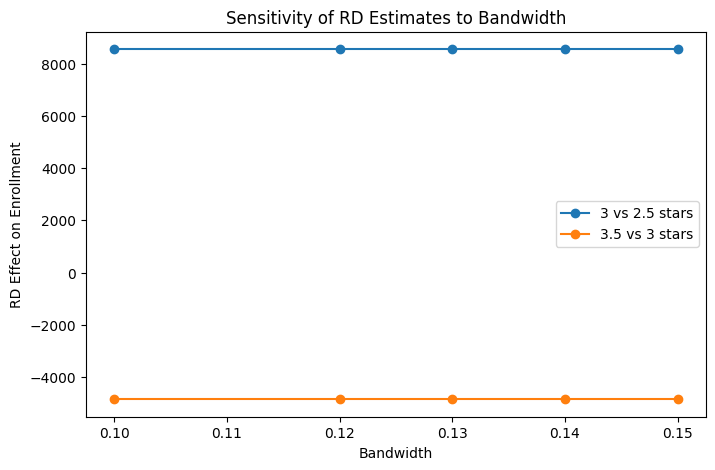

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(bw_results["Bandwidth"], bw_results["3 vs 2.5"], marker="o", label="3 vs 2.5 stars")
plt.plot(bw_results["Bandwidth"], bw_results["3.5 vs 3"], marker="o", label="3.5 vs 3 stars")

plt.xlabel("Bandwidth")
plt.ylabel("RD Effect on Enrollment")
plt.title("Sensitivity of RD Estimates to Bandwidth")
plt.legend()

plt.show()

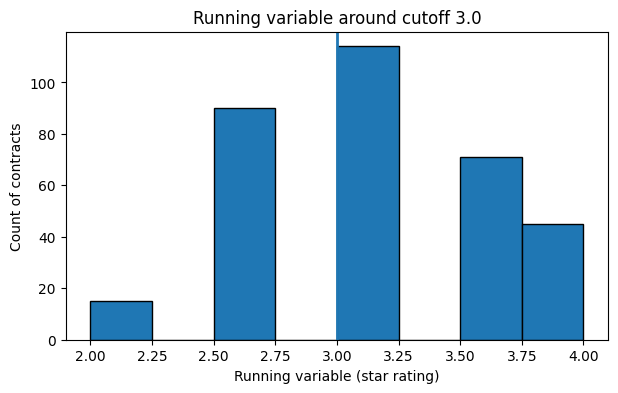

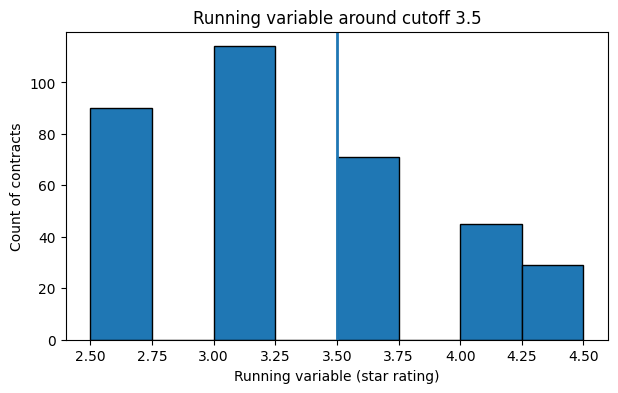

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure running is numeric
df2010["running"] = pd.to_numeric(df2010["running"], errors="coerce")

def plot_running_around_cutoff(df, cutoff, window=1.0, binwidth=0.25):
    x = df["running"].dropna()
    x = x[(x >= cutoff-window) & (x <= cutoff+window)]

    bins = np.arange(cutoff-window, cutoff+window+binwidth, binwidth)

    plt.figure(figsize=(7,4))
    plt.hist(x, bins=bins, edgecolor="black")
    plt.axvline(cutoff, linewidth=2)
    plt.title(f"Running variable around cutoff {cutoff}")
    plt.xlabel("Running variable (star rating)")
    plt.ylabel("Count of contracts")
    plt.show()

plot_running_around_cutoff(df2010, 3.0, window=1.0, binwidth=0.25)
plot_running_around_cutoff(df2010, 3.5, window=1.0, binwidth=0.25)

In [57]:
def counts_near_cutoff(df, cutoff):
    below = (df["running"] == cutoff - 0.5).sum()
    above = (df["running"] == cutoff).sum()
    return pd.Series({"cutoff": cutoff, "count_below": below, "count_above": above})

q8_counts = pd.DataFrame([
    counts_near_cutoff(df2010, 3.0),
    counts_near_cutoff(df2010, 3.5),
])

q8_counts

,cutoff,count_below,count_above
0,3.0,90.0,114.0
1,3.5,114.0,71.0


In [58]:
df2010.columns

Index(['contract_id', 'enroll', 'running'], dtype='object')

In [59]:
import zipfile

zip_path = "Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip"

with zipfile.ZipFile(zip_path) as z:
    contract_info = pd.read_csv(z.open("CPSC_Contract_Info_2010_01.csv"))

contract_info.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xab in position 20721: invalid start byte

In [60]:
import zipfile

zip_path = "Medicare-Advantage/ma-data/ma/enrollment/CPSC-Enrollment-2010-01.zip"

with zipfile.ZipFile(zip_path) as z:
    contract_info = pd.read_csv(
        z.open("CPSC_Contract_Info_2010_01.csv"),
        encoding="latin1"
    )

contract_info.head()

,Contract ID,Plan ID,Organization Type,Plan Type,Offers Part D,SNP Plan,EGHP,Organization Name,Organization Marketing Name,Plan Name,Parent Organization,Contract Effective Date
0,90091,NaN,HCPP - 1833 Cost,HCPP - 1833 Cost,No,No,No,UNITED MINE WORKERS OF AMERICA HEALTH & RETIRE...,United Mine Workers of America Health & Retire...,NaN,UNITED MINE WORKERS OF AMERICA,2/1/1974 0:00:00
1,E0654,801.0,Employer/Union Only Direct Contract PDP,Employer/Union Only Direct Contract PDP,Yes,No,Yes,IBT VOLUNTARY EMPLOYEE BENEFITS TRUST,TEAMStar Medicare Part D Prescription Drug Pro...,IBT VEBA (Employer PDP),IBT Voluntary Employee Benefits Trust,1/1/2007 0:00:00
2,E2332,801.0,Employer/Union Only Direct Contract PDP,Employer/Union Only Direct Contract PDP,Yes,No,Yes,NATIONAL RURAL ELECTRIC COOPERATIVE ASSOCIATION,National Rural Electric Cooperative Association,NRECA Medicare Part D Plan (Employer PDP),National Rural Electric Cooperative Association,1/1/2007 0:00:00
3,E2630,801.0,Employer/Union Only Direct Contract PDP,Employer/Union Only Direct Contract PDP,Yes,No,Yes,C AND O EMPLOYEES HOSPITAL ASSOCIATION,C and O Employees Hospital Association,C and O Employees Hospital Association (Employ...,C & O Employees' Hospital Association,1/1/2007 0:00:00
4,E2868,801.0,Employer/Union Only Direct Contract PDP,Employer/Union Only Direct Contract PDP,Yes,No,Yes,CARPENTER'S HEALTH AND WELFARE TRUST FUND OF STL,Carpenters' District Council of Greater St. Louis,Carpenters' 2010 Plan (Employer PDP),Carpenters H&W Trust Fund of St. Louis,1/1/2007 0:00:00


In [61]:
contract_info.columns

Index(['Contract ID', 'Plan ID', 'Organization Type', 'Plan Type',
       'Offers Part D', 'SNP Plan', 'EGHP', 'Organization Name',
       'Organization Marketing Name', 'Plan Name', 'Parent Organization',
       'Contract Effective Date'],
      dtype='object')

In [62]:
import numpy as np
import pandas as pd

# standardize strings
contract_info["Contract ID"] = contract_info["Contract ID"].astype(str).str.strip()
df2010["contract_id"] = df2010["contract_id"].astype(str).str.strip()

contract_info["Plan Type"] = contract_info["Plan Type"].astype(str).str.strip().str.upper()
contract_info["Offers Part D"] = contract_info["Offers Part D"].astype(str).str.strip().str.upper()

# indicators
contract_info["is_hmo"] = (contract_info["Plan Type"] == "HMO").astype(int)
contract_info["is_partd"] = contract_info["Offers Part D"].isin(["Y", "YES", "TRUE", "1"]).astype(int)

# keep one row per contract (if multiple plans, this collapses to contract-level indicator)
contract_chars = (
    contract_info.groupby("Contract ID", as_index=False)[["is_hmo", "is_partd"]]
    .max()
    .rename(columns={"Contract ID": "contract_id"})
)

df2010b = df2010.merge(contract_chars, on="contract_id", how="left")
df2010b[["contract_id","running","enroll","is_hmo","is_partd"]].head()

,contract_id,running,enroll,is_hmo,is_partd
0,H0104,3.0,55865.0,0,1
1,H0117,2.0,2216.0,0,1
2,H0150,3.0,30847.0,0,1
3,H0151,3.0,32661.0,0,1
4,H0154,3.5,29714.0,0,1


In [63]:
def balance_at_cutoff(df, cutoff):
    below = df[df["running"] == cutoff - 0.5]
    above = df[df["running"] == cutoff]

    return pd.Series({
        "cutoff": cutoff,
        "n_below": len(below),
        "n_above": len(above),
        "HMO_share_below": below["is_hmo"].mean(),
        "HMO_share_above": above["is_hmo"].mean(),
        "HMO_diff": above["is_hmo"].mean() - below["is_hmo"].mean(),
        "PartD_share_below": below["is_partd"].mean(),
        "PartD_share_above": above["is_partd"].mean(),
        "PartD_diff": above["is_partd"].mean() - below["is_partd"].mean(),
    })

q9_table = pd.DataFrame([
    balance_at_cutoff(df2010b, 3.0),
    balance_at_cutoff(df2010b, 3.5),
])

q9_table

,cutoff,n_below,n_above,HMO_share_below,HMO_share_above,HMO_diff,PartD_share_below,PartD_share_above,PartD_diff
0,3.0,90.0,114.0,0.0,0.0,0.0,0.977778,0.991228,0.013450
1,3.5,114.0,71.0,0.0,0.0,0.0,0.991228,1.000000,0.008772


In [64]:
contract_info["is_hmo"] = contract_info["Plan Type"].str.contains("HMO", case=False, na=False).astype(int)

In [65]:
contract_chars = (
    contract_info.groupby("Contract ID", as_index=False)[["is_hmo", "is_partd"]]
    .max()
    .rename(columns={"Contract ID": "contract_id"})
)

df2010b = df2010.merge(contract_chars, on="contract_id", how="left")

q9_table = pd.DataFrame([
    balance_at_cutoff(df2010b, 3.0),
    balance_at_cutoff(df2010b, 3.5),
])

q9_table

,cutoff,n_below,n_above,HMO_share_below,HMO_share_above,HMO_diff,PartD_share_below,PartD_share_above,PartD_diff
0,3.0,90.0,114.0,0.677778,0.710526,0.032749,0.977778,0.991228,0.013450
1,3.5,114.0,71.0,0.710526,0.690141,-0.020385,0.991228,1.000000,0.008772


In [66]:
df2010b["is_hmo"].value_counts()

is_hmo
1    259
0    108
Name: count, dtype: int64